In [ ]:
import sys
sys.path.append("..")

import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, visualize_connectivity_with_non_local_couplings
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE, create_2d_square_lattice_connectivity, setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn,setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn, setup_overdamped_ODE, solve_ODE

jax.config.update("jax_enable_x64", True)

Current working directory: /home/cbosch/dev/oscillator_dev/mechanical-p-bit/projects/physical-diffusion-models/notebooks


2025-03-26 19:51:55.185445: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.8.93. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


ImportError: cannot import name 'setup_overdamped_ODE' from 'physical_diffusion_fns.network_fns' (/home/cbosch/dev/oscillator_dev/mechanical-p-bit/projects/physical-diffusion-models/notebooks/../physical_diffusion_fns/network_fns.py)

# Setup Problem

### Generate samples from a Gaussian mixture - the target distribution

In [5]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [1., 1.],   # mean of first Gaussian
    [-1., -1.],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

In [2]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Network size and topology

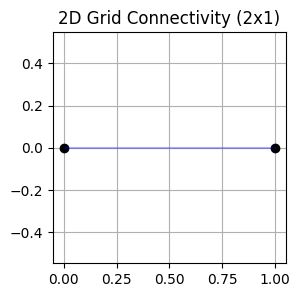

In [4]:
N_osc = 2
connectivity = jnp.array([[0, 1]])
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

### Setup initial params 

In [5]:
k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])

params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)
params_names = ["k_lin", "k_duff", "c_lin", "c_optomech"]
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)

# some initial guess from skewed distribution


params_flattened_initial = jnp.array([-614.42648671,  588.10603632,  482.38294911, 1459.22532574,
         81.11413943,    0.        ])



### Build energy

In [6]:
energy_fn = setup_duffing_network_energy_fn(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


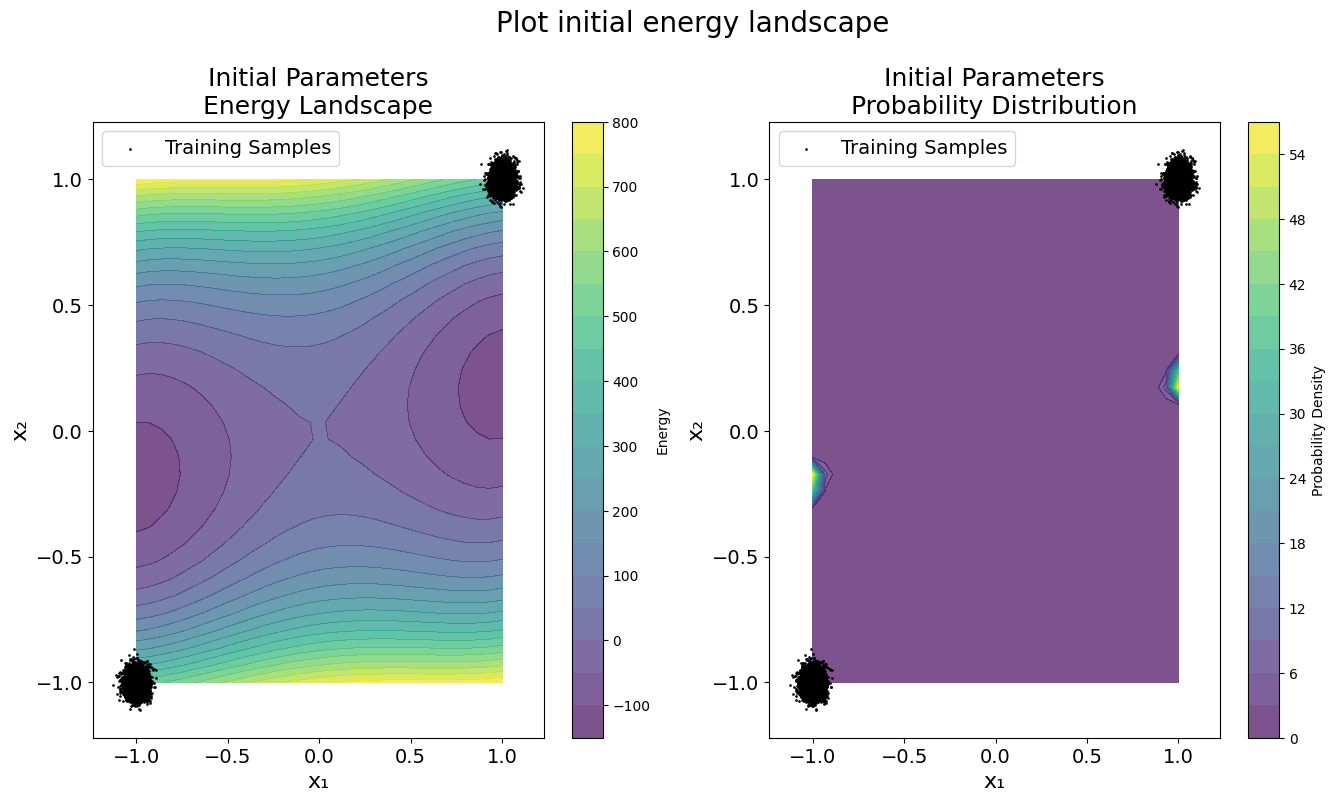

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 300
t_forward = 1.0
sigma_forward = .5
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-20), jnp.log(t_forward), n_time_steps))
forward_time_pts = forward_time_pts.at[0].set(0.)

# Optimization parameters
learning_rate = 1.
n_epochs = 100000//2
batch_size = 2*128
window_size=1000
tolerance=1e-16
patience=50


In [10]:
comment = ""
optimization_folder = (f"{training_method}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}_"
           f"{comment}")

In [11]:
# Setup output directories
base_dir = "out/problems"
problem_type_folder = "mixture_gaussians_sampling"
problem_folder = f"weights_{weights}_means_{means.flatten()}"  # Replace with your actual parameters

output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)

### Print final distribution of the forward

Saving figure to out/problems/mixture_gaussians_sampling/weights_[0.5 0.5]_means_[ 1.  1. -1. -1.]/SM_t_forward_1.0_n_timesteps_300_lr_1.0_epochs_50000_batch_256_window_1000_tol_1e-16_patience_50_


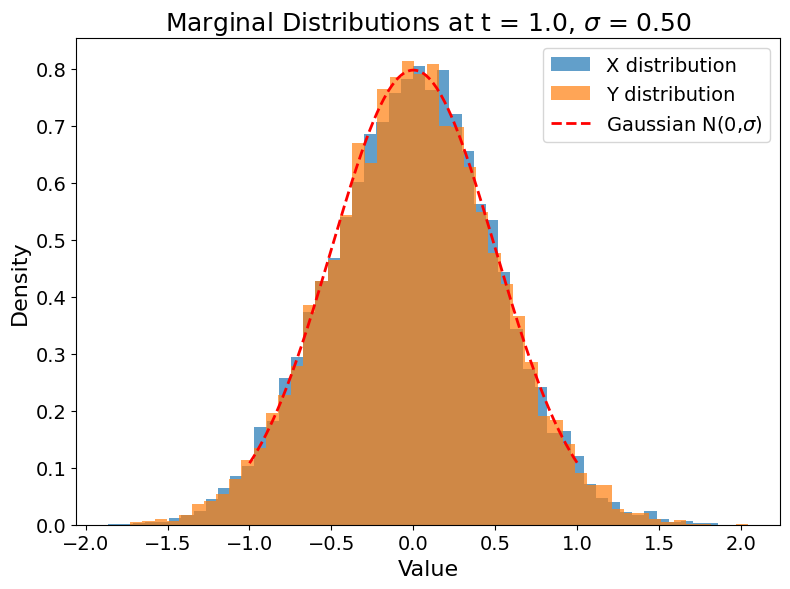

In [12]:
key, subkey = jr.split(key)
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey)
plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=True, fontsize=16)

Optimization for time 0.0
Epoch 0 - Loss: 2132615.7446
Epoch 100 - Loss: 1751490.5446
Epoch 200 - Loss: 1404489.8249
Epoch 300 - Loss: 1115172.3765
Epoch 400 - Loss: 885775.2193
Epoch 500 - Loss: 697288.3478
Epoch 600 - Loss: 520621.9776
Epoch 700 - Loss: 395166.3290
Epoch 800 - Loss: 292187.3221
Epoch 900 - Loss: 208947.7400
Epoch 1000 - Loss: 151833.9545
Epoch 1100 - Loss: 107916.3807
Epoch 1200 - Loss: 71885.9032
Epoch 1300 - Loss: 46680.8757
Epoch 1400 - Loss: 30573.0021
Epoch 1500 - Loss: 18971.0610
Epoch 1600 - Loss: 10982.5761
Epoch 1700 - Loss: 5747.7695
Epoch 1800 - Loss: 2877.2817
Epoch 1900 - Loss: 1543.9252
Epoch 2000 - Loss: 81.0170
Epoch 2100 - Loss: -167.2478
Epoch 2200 - Loss: -831.3999
Epoch 2300 - Loss: -877.5117
Epoch 2400 - Loss: -869.3187
Epoch 2500 - Loss: -894.7523
Epoch 2600 - Loss: -891.2966
Epoch 2700 - Loss: -1071.2301
Epoch 2800 - Loss: -996.8668
Epoch 2900 - Loss: -979.1320
Epoch 3000 - Loss: -1008.7614
Epoch 3100 - Loss: -1025.1160
Epoch 3200 - Loss: -1023

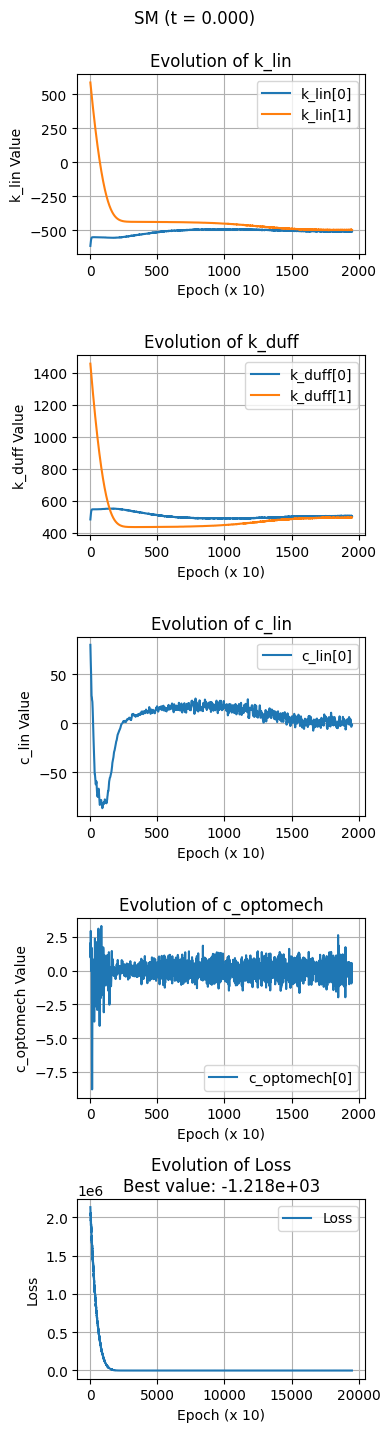

Optimization for time 1.1665131316981968e-20
Epoch 0 - Loss: -982.3983
Epoch 100 - Loss: -1025.7021
Epoch 200 - Loss: -1101.8173
Epoch 300 - Loss: -975.6136
Epoch 400 - Loss: -887.0142
Epoch 500 - Loss: -923.7260
Epoch 600 - Loss: -954.1179
Epoch 700 - Loss: -1034.7158
Epoch 800 - Loss: -1023.6786
Epoch 900 - Loss: -1185.0251
Epoch 1000 - Loss: -944.3986
Epoch 1100 - Loss: -992.2346
Epoch 1200 - Loss: -1021.8607
Epoch 1300 - Loss: -908.3671
Epoch 1400 - Loss: -1073.2728
Epoch 1500 - Loss: -977.0859
Epoch 1600 - Loss: -937.5285
Epoch 1700 - Loss: -1002.3551
Epoch 1800 - Loss: -906.1352
Epoch 1900 - Loss: -1059.8952
Epoch 2000 - Loss: -837.3647
Epoch 2100 - Loss: -1074.0668
Epoch 2200 - Loss: -947.8632
Epoch 2300 - Loss: -902.3996
Epoch 2400 - Loss: -1021.7164
Epoch 2500 - Loss: -1075.3132
Epoch 2600 - Loss: -901.5655
Epoch 2700 - Loss: -1119.3166
Epoch 2800 - Loss: -887.2242
Epoch 2900 - Loss: -872.0608
Epoch 3000 - Loss: -915.9735
Epoch 3100 - Loss: -978.3563
Epoch 3200 - Loss: -1001.2

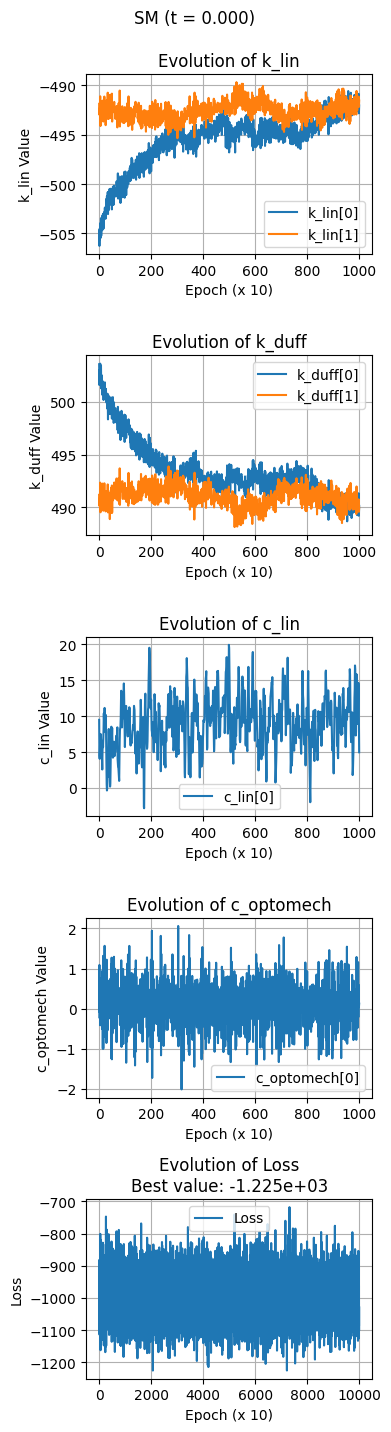

Optimization for time 5.442343548300262e-20
Epoch 0 - Loss: -962.8536
Epoch 100 - Loss: -1029.3165
Epoch 200 - Loss: -1180.9999
Epoch 300 - Loss: -1022.0897
Epoch 400 - Loss: -1049.8762
Epoch 500 - Loss: -1068.9475
Epoch 600 - Loss: -887.0024
Epoch 700 - Loss: -1022.0270
Epoch 800 - Loss: -1079.0938
Epoch 900 - Loss: -1041.5516
Epoch 1000 - Loss: -1041.0006
Epoch 1100 - Loss: -900.5794
Epoch 1200 - Loss: -971.5716
Epoch 1300 - Loss: -1008.9000
Epoch 1400 - Loss: -1003.8056
Epoch 1500 - Loss: -1017.9576
Epoch 1600 - Loss: -1048.5455
Epoch 1700 - Loss: -1099.4651
Epoch 1800 - Loss: -998.5931
Epoch 1900 - Loss: -1015.8947
Epoch 2000 - Loss: -905.9556
Epoch 2100 - Loss: -1031.6160
Epoch 2200 - Loss: -1078.1382
Epoch 2300 - Loss: -944.9745
Epoch 2400 - Loss: -990.9395
Epoch 2500 - Loss: -1033.1169
Epoch 2600 - Loss: -1072.2991
Epoch 2700 - Loss: -1079.9877
Epoch 2800 - Loss: -1019.4333
Epoch 2900 - Loss: -961.0766
Epoch 3000 - Loss: -960.4613
Epoch 3100 - Loss: -982.4916
Epoch 3200 - Loss: 

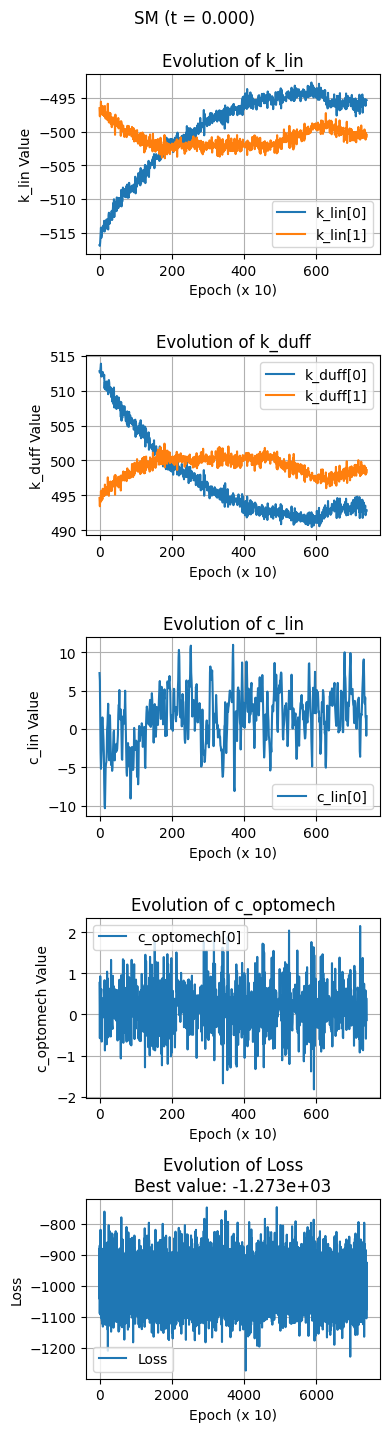

Optimization for time 2.539114433680342e-19
Epoch 0 - Loss: -870.3623
Epoch 100 - Loss: -985.7837
Epoch 200 - Loss: -926.6354
Epoch 300 - Loss: -959.1118
Epoch 400 - Loss: -1010.9070
Epoch 500 - Loss: -1050.4313
Epoch 600 - Loss: -973.5822
Epoch 700 - Loss: -1083.5345
Epoch 800 - Loss: -991.3607
Epoch 900 - Loss: -954.7015
Epoch 1000 - Loss: -1057.0199
Epoch 1100 - Loss: -901.8732
Epoch 1200 - Loss: -996.9961
Epoch 1300 - Loss: -922.3632
Epoch 1400 - Loss: -1087.7150
Epoch 1500 - Loss: -1044.1182
Epoch 1600 - Loss: -1074.0277
Epoch 1700 - Loss: -879.9332
Epoch 1800 - Loss: -1016.0635
Epoch 1900 - Loss: -1080.9903
Epoch 2000 - Loss: -951.2707
Epoch 2100 - Loss: -1014.5761
Epoch 2200 - Loss: -962.8131
Epoch 2300 - Loss: -989.8044
Epoch 2400 - Loss: -1014.7891
Epoch 2500 - Loss: -1004.8439
Epoch 2600 - Loss: -1016.1608
Epoch 2700 - Loss: -1050.4910
Epoch 2800 - Loss: -991.8939
Epoch 2900 - Loss: -991.4304
Epoch 3000 - Loss: -958.8946
Epoch 3100 - Loss: -991.7687
Epoch 3200 - Loss: -1035.0

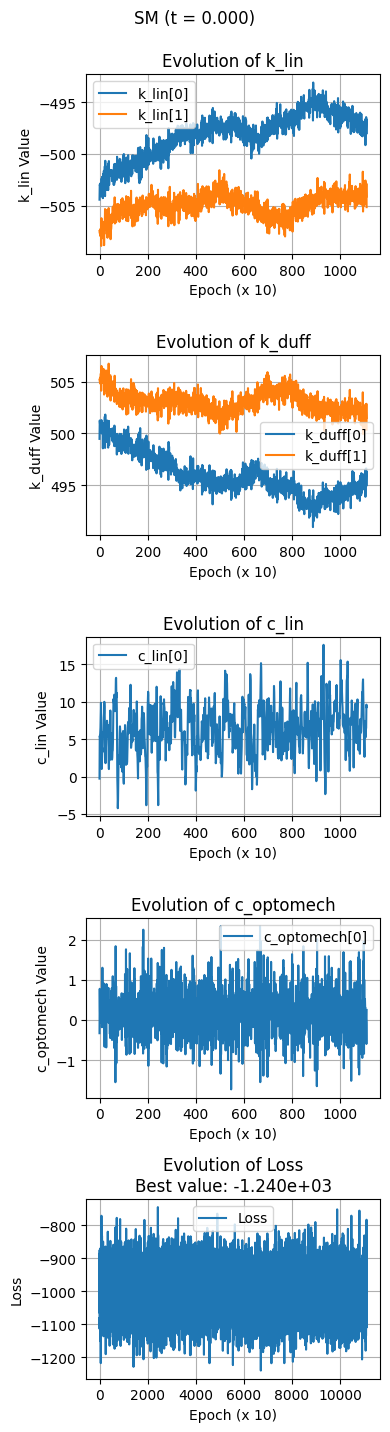

Optimization for time 1.184618730902688e-18
Epoch 0 - Loss: -1018.9838
Epoch 100 - Loss: -1016.1837
Epoch 200 - Loss: -1034.6778
Epoch 300 - Loss: -1003.9990
Epoch 400 - Loss: -1081.1055
Epoch 500 - Loss: -932.0425
Epoch 600 - Loss: -1008.4535
Epoch 700 - Loss: -1091.2124
Epoch 800 - Loss: -903.8420
Epoch 900 - Loss: -1016.4963
Epoch 1000 - Loss: -971.8507
Epoch 1100 - Loss: -1065.6868
Epoch 1200 - Loss: -962.5159
Epoch 1300 - Loss: -1034.4354
Epoch 1400 - Loss: -1050.3467
Epoch 1500 - Loss: -1043.7232
Epoch 1600 - Loss: -940.9632
Epoch 1700 - Loss: -1039.7809
Epoch 1800 - Loss: -1026.0036
Epoch 1900 - Loss: -953.3926
Epoch 2000 - Loss: -948.8274
Epoch 2100 - Loss: -979.8940
Epoch 2200 - Loss: -869.5605
Epoch 2300 - Loss: -1003.6162
Epoch 2400 - Loss: -970.9634
Epoch 2500 - Loss: -886.9384
Epoch 2600 - Loss: -1095.7655
Epoch 2700 - Loss: -1056.7231
Epoch 2800 - Loss: -959.1217
Epoch 2900 - Loss: -943.0694
Epoch 3000 - Loss: -1048.5325
Epoch 3100 - Loss: -924.7209
Epoch 3200 - Loss: -92

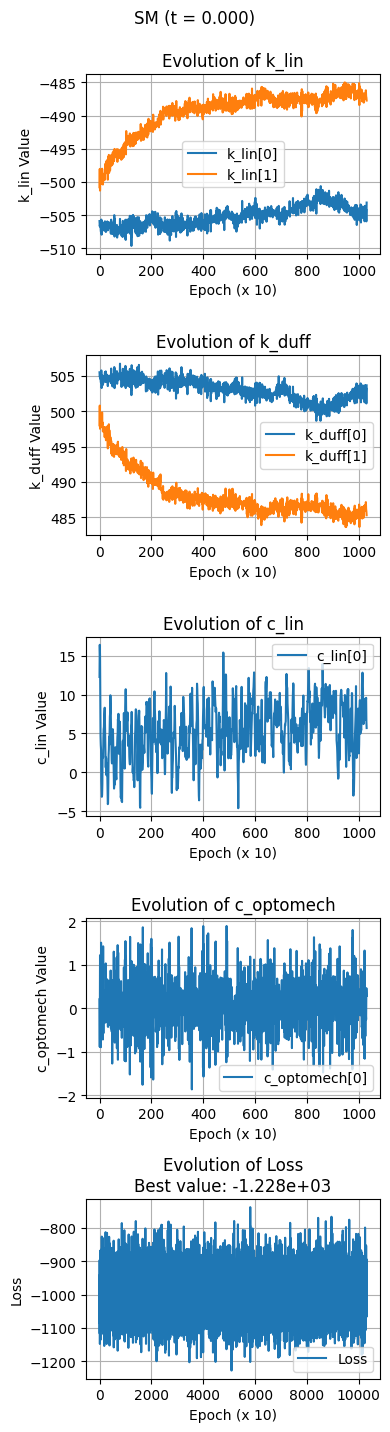

Optimization for time 5.526814857144616e-18
Epoch 0 - Loss: -1020.4136
Epoch 100 - Loss: -1073.8783
Epoch 200 - Loss: -978.2392
Epoch 300 - Loss: -987.2601
Epoch 400 - Loss: -991.4613
Epoch 500 - Loss: -941.9179
Epoch 600 - Loss: -951.5966
Epoch 700 - Loss: -1043.1251
Epoch 800 - Loss: -1003.0011
Epoch 900 - Loss: -1116.4326
Epoch 1000 - Loss: -1066.8392
Epoch 1100 - Loss: -1030.3376
Epoch 1200 - Loss: -989.5647
Epoch 1300 - Loss: -1020.6870
Epoch 1400 - Loss: -958.9624
Epoch 1500 - Loss: -1018.4171
Epoch 1600 - Loss: -911.1405
Epoch 1700 - Loss: -916.9399
Epoch 1800 - Loss: -919.5732
Epoch 1900 - Loss: -1069.6576
Epoch 2000 - Loss: -909.8992
Epoch 2100 - Loss: -935.5439
Epoch 2200 - Loss: -974.2631
Epoch 2300 - Loss: -937.2676
Epoch 2400 - Loss: -1119.3255
Epoch 2500 - Loss: -919.7709
Epoch 2600 - Loss: -1119.2875
Epoch 2700 - Loss: -1160.2139
Epoch 2800 - Loss: -925.5972
Epoch 2900 - Loss: -1073.7227
Epoch 3000 - Loss: -896.4260
Epoch 3100 - Loss: -990.8924
Epoch 3200 - Loss: -938.48

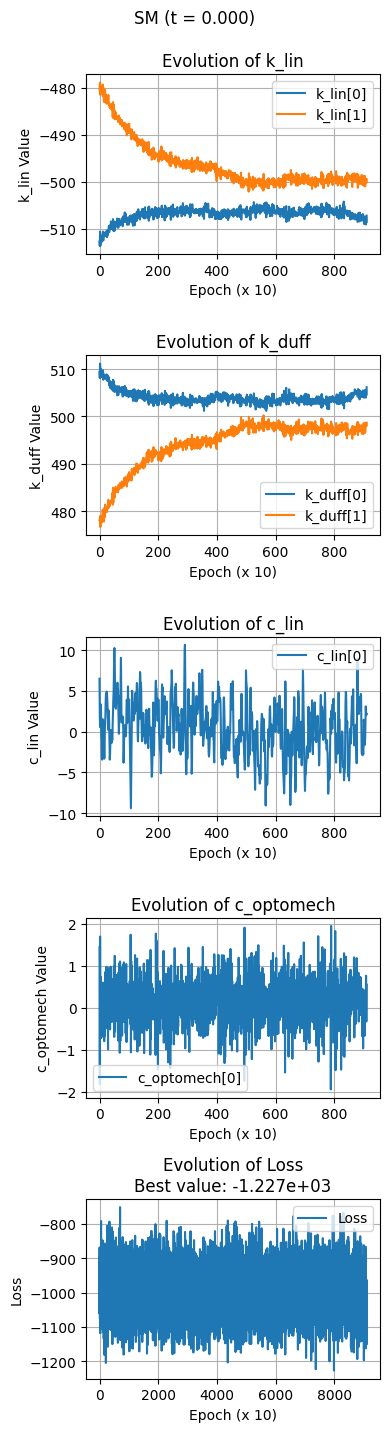

Optimization for time 2.5785243528842764e-17
Epoch 0 - Loss: -879.3295
Epoch 100 - Loss: -1032.7670
Epoch 200 - Loss: -935.2606
Epoch 300 - Loss: -991.1368
Epoch 400 - Loss: -1057.4635
Epoch 500 - Loss: -934.6216
Epoch 600 - Loss: -972.8729
Epoch 700 - Loss: -924.6814
Epoch 800 - Loss: -1135.3283
Epoch 900 - Loss: -1123.3679
Epoch 1000 - Loss: -1012.0899
Epoch 1100 - Loss: -1069.4384
Epoch 1200 - Loss: -941.5985
Epoch 1300 - Loss: -912.3992
Epoch 1400 - Loss: -1037.7990
Epoch 1500 - Loss: -1143.3388
Epoch 1600 - Loss: -1050.6359
Epoch 1700 - Loss: -983.6876
Epoch 1800 - Loss: -1201.4611
Epoch 1900 - Loss: -1052.0732
Epoch 2000 - Loss: -1128.3679
Epoch 2100 - Loss: -1085.4453
Epoch 2200 - Loss: -901.7692
Epoch 2300 - Loss: -992.3967
Epoch 2400 - Loss: -978.9191
Epoch 2500 - Loss: -993.7101
Epoch 2600 - Loss: -976.6813
Epoch 2700 - Loss: -1082.4734
Epoch 2800 - Loss: -1108.5404
Epoch 2900 - Loss: -1047.5341
Epoch 3000 - Loss: -1087.1070
Epoch 3100 - Loss: -917.1172
Epoch 3200 - Loss: -10

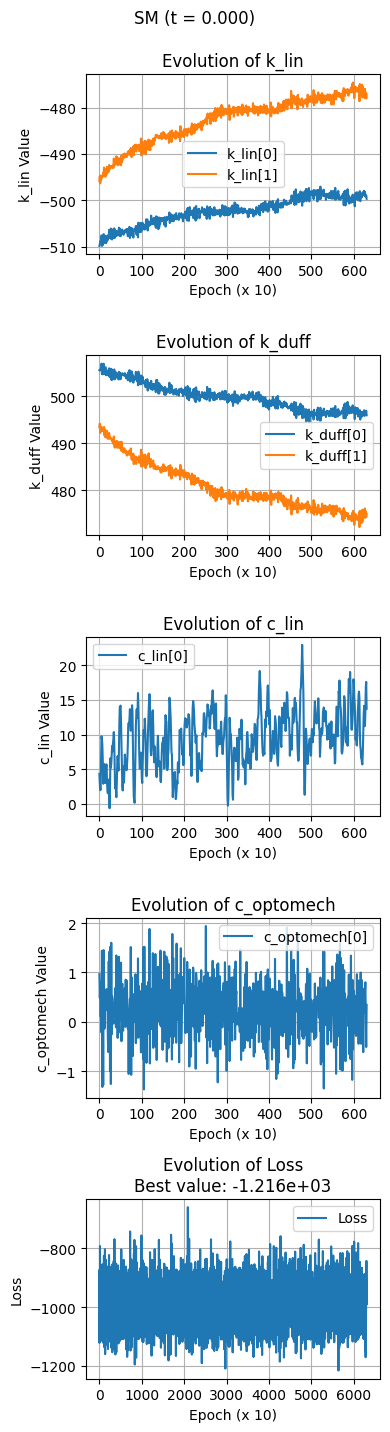

Optimization for time 1.2030053494233237e-16
Epoch 0 - Loss: -1040.2874
Epoch 100 - Loss: -936.3020
Epoch 200 - Loss: -897.6922
Epoch 300 - Loss: -1036.0464
Epoch 400 - Loss: -973.0347
Epoch 500 - Loss: -1050.2489
Epoch 600 - Loss: -1089.3732
Epoch 700 - Loss: -972.9780
Epoch 800 - Loss: -1062.7059
Epoch 900 - Loss: -971.5382
Epoch 1000 - Loss: -1071.5448
Epoch 1100 - Loss: -1076.1707
Epoch 1200 - Loss: -1098.5842
Epoch 1300 - Loss: -953.5698
Epoch 1400 - Loss: -1073.8222
Epoch 1500 - Loss: -1087.5463
Epoch 1600 - Loss: -987.9844
Epoch 1700 - Loss: -1088.0153
Epoch 1800 - Loss: -1032.7641
Epoch 1900 - Loss: -1016.8572
Epoch 2000 - Loss: -968.3950
Epoch 2100 - Loss: -1006.4726
Epoch 2200 - Loss: -1082.6933
Epoch 2300 - Loss: -1016.4236
Epoch 2400 - Loss: -1070.7720
Epoch 2500 - Loss: -979.8183
Epoch 2600 - Loss: -1010.2729
Epoch 2700 - Loss: -1019.5119
Epoch 2800 - Loss: -971.4926
Epoch 2900 - Loss: -904.4362
Epoch 3000 - Loss: -1058.4746
Epoch 3100 - Loss: -963.7624
Epoch 3200 - Loss: 

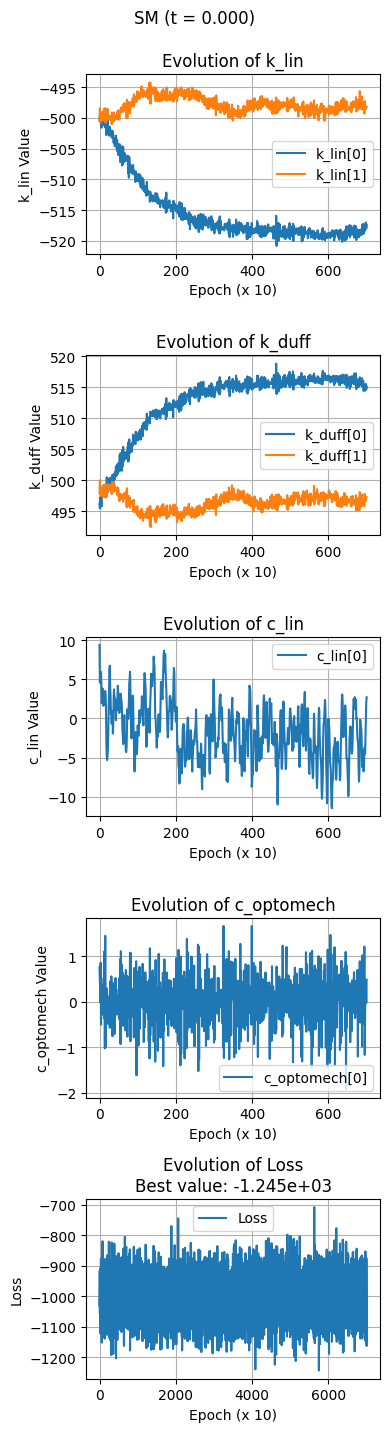

Optimization for time 5.612597255954962e-16
Epoch 0 - Loss: -1103.1689
Epoch 100 - Loss: -1115.9965
Epoch 200 - Loss: -1110.2086
Epoch 300 - Loss: -1116.2238
Epoch 400 - Loss: -1062.7889
Epoch 500 - Loss: -1103.2260
Epoch 600 - Loss: -1109.6386
Epoch 700 - Loss: -1033.7221
Epoch 800 - Loss: -1030.7412
Epoch 900 - Loss: -950.3511
Epoch 1000 - Loss: -981.3799
Epoch 1100 - Loss: -1083.0775
Epoch 1200 - Loss: -995.3309
Epoch 1300 - Loss: -1052.8619
Epoch 1400 - Loss: -825.2084
Epoch 1500 - Loss: -1143.2516
Epoch 1600 - Loss: -925.2341
Epoch 1700 - Loss: -1099.5382
Epoch 1800 - Loss: -1011.2653
Epoch 1900 - Loss: -1003.4202
Epoch 2000 - Loss: -1072.7246
Epoch 2100 - Loss: -1083.0794
Epoch 2200 - Loss: -1078.4601
Epoch 2300 - Loss: -1048.0672
Epoch 2400 - Loss: -1059.7989
Epoch 2500 - Loss: -875.4880
Epoch 2600 - Loss: -982.5832
Epoch 2700 - Loss: -964.0428
Epoch 2800 - Loss: -967.2938
Epoch 2900 - Loss: -1121.5892
Epoch 3000 - Loss: -950.9721
Epoch 3100 - Loss: -1118.8890
Epoch 3200 - Loss:

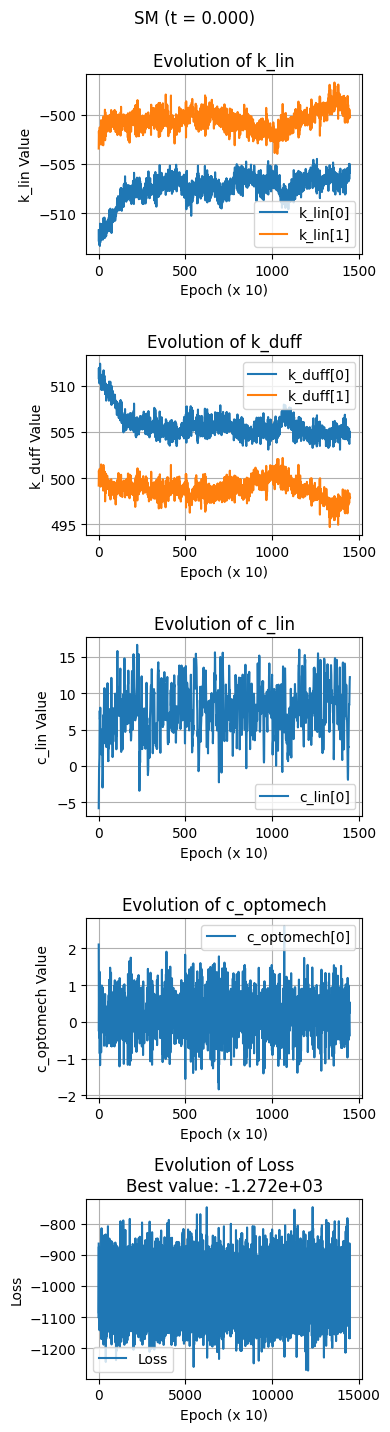

Optimization for time 2.618545958474243e-15
Epoch 0 - Loss: -1000.1899
Epoch 100 - Loss: -1050.2039
Epoch 200 - Loss: -961.0550
Epoch 300 - Loss: -1030.1038
Epoch 400 - Loss: -973.0220
Epoch 500 - Loss: -1048.9612
Epoch 600 - Loss: -984.8860
Epoch 700 - Loss: -984.4489
Epoch 800 - Loss: -1021.2803
Epoch 900 - Loss: -1037.2311
Epoch 1000 - Loss: -1125.7888
Epoch 1100 - Loss: -1122.7115
Epoch 1200 - Loss: -1008.0046
Epoch 1300 - Loss: -902.2729
Epoch 1400 - Loss: -946.1089
Epoch 1500 - Loss: -957.6416
Epoch 1600 - Loss: -1095.4973
Epoch 1700 - Loss: -899.8365
Epoch 1800 - Loss: -891.5850
Epoch 1900 - Loss: -1081.7375
Epoch 2000 - Loss: -966.6297
Epoch 2100 - Loss: -1079.4568
Epoch 2200 - Loss: -1100.8407
Epoch 2300 - Loss: -1056.9300
Epoch 2400 - Loss: -1098.7711
Epoch 2500 - Loss: -1005.6453
Epoch 2600 - Loss: -977.1347
Epoch 2700 - Loss: -1031.6533
Epoch 2800 - Loss: -1049.2117
Epoch 2900 - Loss: -1043.3915
Epoch 3000 - Loss: -895.7309
Epoch 3100 - Loss: -858.1470
Epoch 3200 - Loss: -1

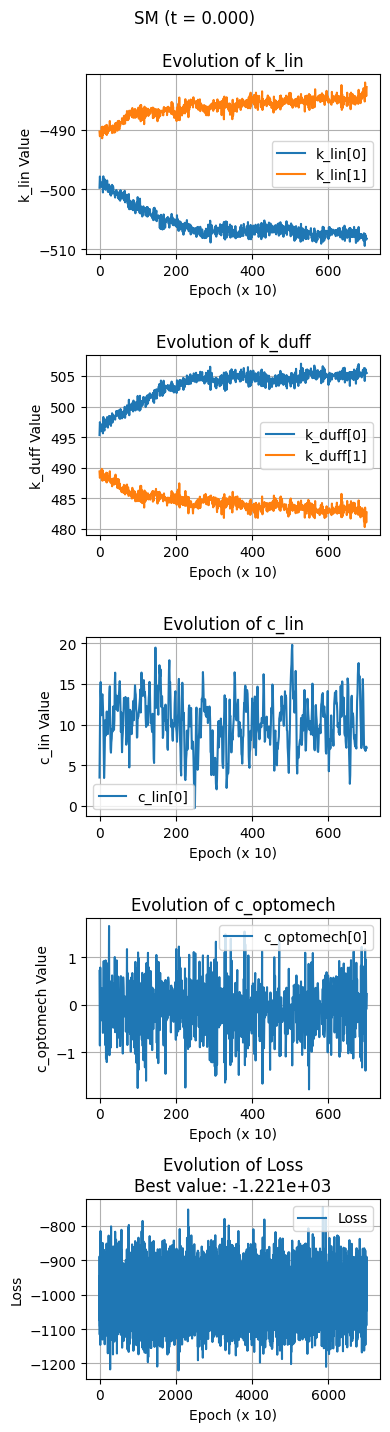

Optimization for time 1.2216773489967951e-14
Epoch 0 - Loss: -937.8617
Epoch 100 - Loss: -1058.3902
Epoch 200 - Loss: -966.8557
Epoch 300 - Loss: -1030.0034
Epoch 400 - Loss: -1140.9689
Epoch 500 - Loss: -1082.4622
Epoch 600 - Loss: -956.4615
Epoch 700 - Loss: -1008.4494
Epoch 800 - Loss: -1086.5763
Epoch 900 - Loss: -974.1981
Epoch 1000 - Loss: -1012.8428
Epoch 1100 - Loss: -1012.9502
Epoch 1200 - Loss: -1090.1954
Epoch 1300 - Loss: -978.6439
Epoch 1400 - Loss: -1054.1721
Epoch 1500 - Loss: -1064.8787
Epoch 1600 - Loss: -921.4169
Epoch 1700 - Loss: -987.4548
Epoch 1800 - Loss: -1004.9741
Epoch 1900 - Loss: -1038.0860
Epoch 2000 - Loss: -1145.2754
Epoch 2100 - Loss: -1015.8164
Epoch 2200 - Loss: -1071.2784
Epoch 2300 - Loss: -1034.5434
Epoch 2400 - Loss: -990.3842
Epoch 2500 - Loss: -1005.8581
Epoch 2600 - Loss: -1046.2299
Epoch 2700 - Loss: -974.8219
Epoch 2800 - Loss: -1020.5451
Epoch 2900 - Loss: -906.5686
Epoch 3000 - Loss: -1063.3574
Epoch 3100 - Loss: -1024.4784
Epoch 3200 - Loss

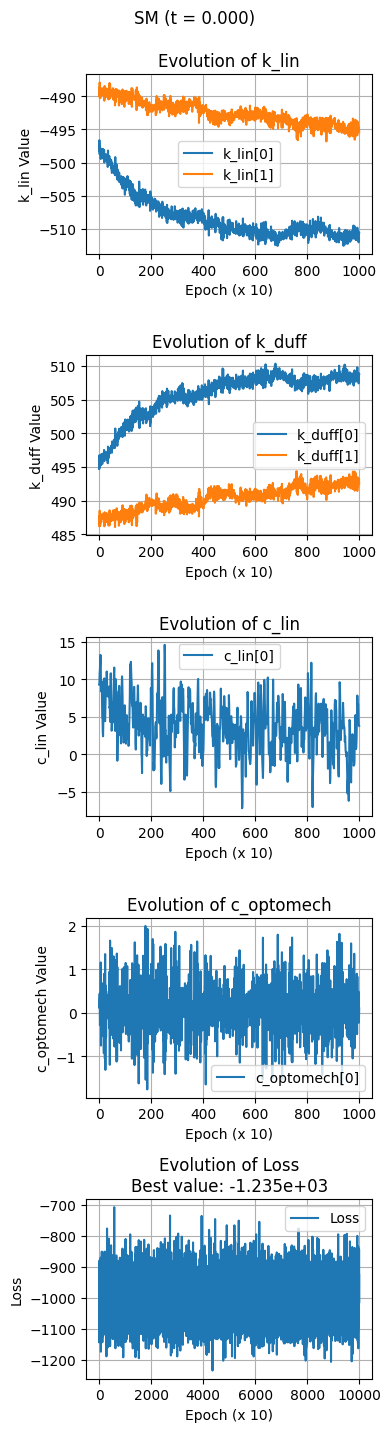

Optimization for time 5.699711094326062e-14
Epoch 0 - Loss: -1068.9711
Epoch 100 - Loss: -1016.0156
Epoch 200 - Loss: -1012.4846
Epoch 300 - Loss: -959.7577
Epoch 400 - Loss: -1053.6359
Epoch 500 - Loss: -1093.8424
Epoch 600 - Loss: -877.8393
Epoch 700 - Loss: -1037.7847
Epoch 800 - Loss: -1015.9301
Epoch 900 - Loss: -913.2664
Epoch 1000 - Loss: -911.2837
Epoch 1100 - Loss: -1014.3466
Epoch 1200 - Loss: -1083.3708
Epoch 1300 - Loss: -914.4090
Epoch 1400 - Loss: -977.6523
Epoch 1500 - Loss: -1048.6608
Epoch 1600 - Loss: -1036.4548
Epoch 1700 - Loss: -918.2707
Epoch 1800 - Loss: -884.5613
Epoch 1900 - Loss: -1063.8167
Epoch 2000 - Loss: -933.2177
Epoch 2100 - Loss: -1055.1794
Epoch 2200 - Loss: -939.1401
Epoch 2300 - Loss: -1009.4469
Epoch 2400 - Loss: -908.9607
Epoch 2500 - Loss: -1046.5212
Epoch 2600 - Loss: -999.3969
Epoch 2700 - Loss: -1061.1969
Epoch 2800 - Loss: -984.7328
Epoch 2900 - Loss: -1067.4980
Epoch 3000 - Loss: -1028.2335
Epoch 3100 - Loss: -1032.5676
Epoch 3200 - Loss: -1

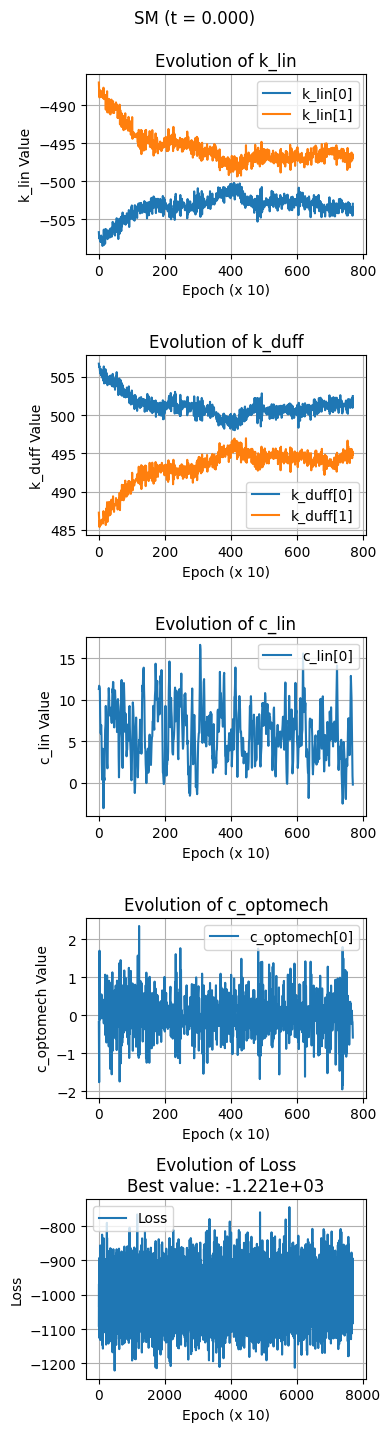

Optimization for time 2.6591887445126936e-13
Epoch 0 - Loss: -948.4737
Epoch 100 - Loss: -1070.9957
Epoch 200 - Loss: -877.5613
Epoch 300 - Loss: -1144.1532
Epoch 400 - Loss: -987.9533
Epoch 500 - Loss: -985.8029
Epoch 600 - Loss: -1010.6076
Epoch 700 - Loss: -1212.9805
Epoch 800 - Loss: -1050.8821
Epoch 900 - Loss: -952.0081
Epoch 1000 - Loss: -966.6466
Epoch 1100 - Loss: -1079.6771
Epoch 1200 - Loss: -972.2694
Epoch 1300 - Loss: -943.7499
Epoch 1400 - Loss: -1072.5281
Epoch 1500 - Loss: -1043.3079
Epoch 1600 - Loss: -923.0511
Epoch 1700 - Loss: -1003.9730
Epoch 1800 - Loss: -928.1351
Epoch 1900 - Loss: -943.8732
Epoch 2000 - Loss: -1103.1027
Epoch 2100 - Loss: -974.1967
Epoch 2200 - Loss: -955.9608
Epoch 2300 - Loss: -1116.1865
Epoch 2400 - Loss: -1086.5284
Epoch 2500 - Loss: -1037.6802
Epoch 2600 - Loss: -1052.8851
Epoch 2700 - Loss: -1004.2622
Epoch 2800 - Loss: -1079.3884
Epoch 2900 - Loss: -1008.4826
Epoch 3000 - Loss: -1031.6336
Epoch 3100 - Loss: -1131.7280
Epoch 3200 - Loss: -

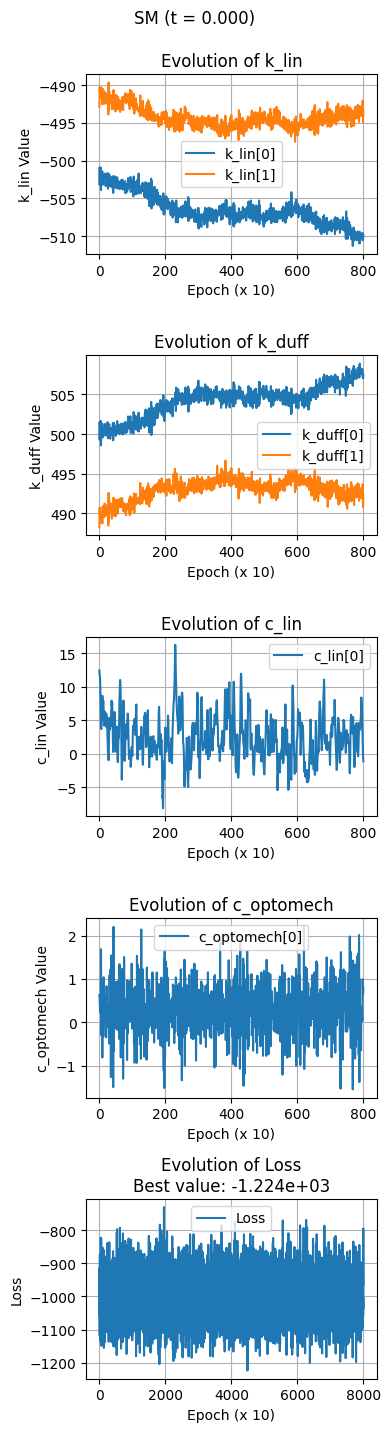

Optimization for time 1.24063915905883e-12
Epoch 0 - Loss: -1029.4979
Epoch 100 - Loss: -973.5624
Epoch 200 - Loss: -1125.8009
Epoch 300 - Loss: -1126.7070
Epoch 400 - Loss: -1009.4759
Epoch 500 - Loss: -951.4743
Epoch 600 - Loss: -1118.6823
Epoch 700 - Loss: -968.1956
Epoch 800 - Loss: -876.9900
Epoch 900 - Loss: -1049.5802
Epoch 1000 - Loss: -1033.8733
Epoch 1100 - Loss: -1057.5520
Epoch 1200 - Loss: -984.1430
Epoch 1300 - Loss: -991.0037
Epoch 1400 - Loss: -997.7799
Epoch 1500 - Loss: -1100.8703
Epoch 1600 - Loss: -930.1174
Epoch 1700 - Loss: -1064.4119
Epoch 1800 - Loss: -966.5753
Epoch 1900 - Loss: -1022.0193
Epoch 2000 - Loss: -1092.5486
Epoch 2100 - Loss: -1081.8172
Epoch 2200 - Loss: -993.1809
Epoch 2300 - Loss: -992.1022
Epoch 2400 - Loss: -1003.9674
Epoch 2500 - Loss: -1090.2583
Epoch 2600 - Loss: -1048.4152
Epoch 2700 - Loss: -1089.9231
Epoch 2800 - Loss: -1060.9613
Epoch 2900 - Loss: -907.3049
Epoch 3000 - Loss: -1089.5486
Epoch 3100 - Loss: -977.9335
Epoch 3200 - Loss: -11

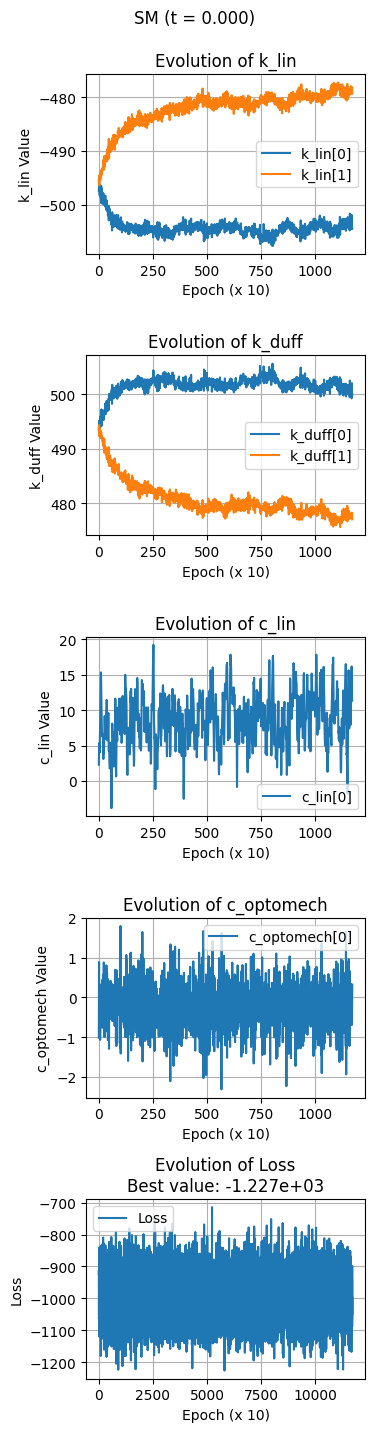

Optimization for time 5.788177037701279e-12
Epoch 0 - Loss: -943.4609
Epoch 100 - Loss: -971.8186
Epoch 200 - Loss: -854.0240
Epoch 300 - Loss: -1016.4277
Epoch 400 - Loss: -990.9779
Epoch 500 - Loss: -918.3141
Epoch 600 - Loss: -998.4820
Epoch 700 - Loss: -839.0137
Epoch 800 - Loss: -903.2674
Epoch 900 - Loss: -1068.6514
Epoch 1000 - Loss: -1026.5634
Epoch 1100 - Loss: -1034.6198
Epoch 1200 - Loss: -946.0536
Epoch 1300 - Loss: -940.8094
Epoch 1400 - Loss: -913.2147
Epoch 1500 - Loss: -1086.3547
Epoch 1600 - Loss: -990.5030
Epoch 1700 - Loss: -995.5361
Epoch 1800 - Loss: -1004.4979
Epoch 1900 - Loss: -1062.0601
Epoch 2000 - Loss: -981.3036
Epoch 2100 - Loss: -997.8867
Epoch 2200 - Loss: -980.1019
Epoch 2300 - Loss: -1024.9524
Epoch 2400 - Loss: -1014.2550
Epoch 2500 - Loss: -885.0864
Epoch 2600 - Loss: -1009.4807
Epoch 2700 - Loss: -918.6893
Epoch 2800 - Loss: -956.1626
Epoch 2900 - Loss: -1139.8976
Epoch 3000 - Loss: -900.1636
Epoch 3100 - Loss: -943.8955
Epoch 3200 - Loss: -997.0406


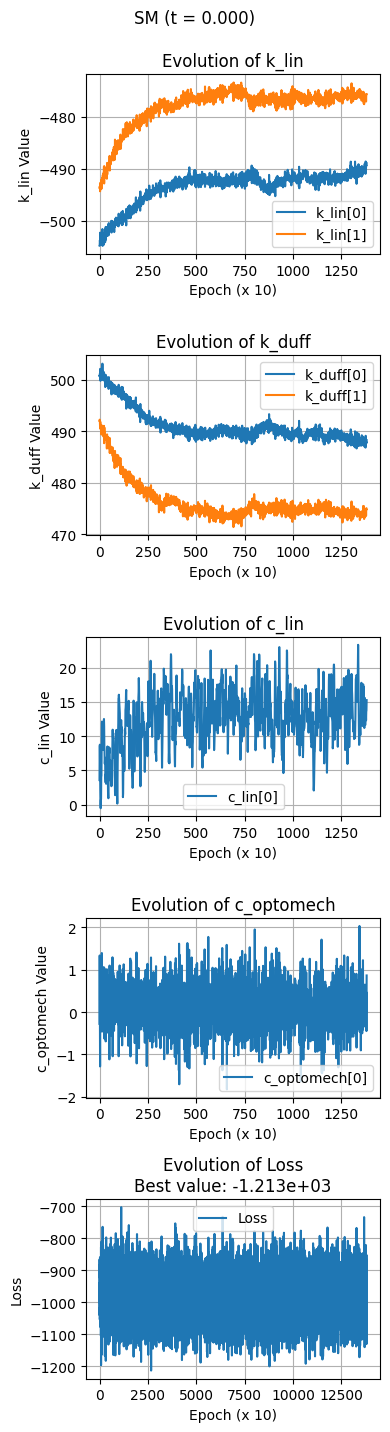

Optimization for time 2.7004623524206808e-11
Epoch 0 - Loss: -1053.8193
Epoch 100 - Loss: -911.5787
Epoch 200 - Loss: -987.0746
Epoch 300 - Loss: -962.2639
Epoch 400 - Loss: -966.0958
Epoch 500 - Loss: -1026.5143
Epoch 600 - Loss: -1150.5819
Epoch 700 - Loss: -997.1683
Epoch 800 - Loss: -972.5251
Epoch 900 - Loss: -1032.6221
Epoch 1000 - Loss: -968.9065
Epoch 1100 - Loss: -843.8683
Epoch 1200 - Loss: -940.0199
Epoch 1300 - Loss: -1029.3259
Epoch 1400 - Loss: -987.8554
Epoch 1500 - Loss: -1023.6454
Epoch 1600 - Loss: -990.5945
Epoch 1700 - Loss: -911.2579
Epoch 1800 - Loss: -985.5729
Epoch 1900 - Loss: -1096.9831
Epoch 2000 - Loss: -992.3042
Epoch 2100 - Loss: -945.3947
Epoch 2200 - Loss: -1039.1655
Epoch 2300 - Loss: -953.9217
Epoch 2400 - Loss: -919.1112
Epoch 2500 - Loss: -1019.4752
Epoch 2600 - Loss: -918.8107
Epoch 2700 - Loss: -835.9297
Epoch 2800 - Loss: -1011.8045
Epoch 2900 - Loss: -933.1010
Epoch 3000 - Loss: -977.0674
Epoch 3100 - Loss: -972.5003
Epoch 3200 - Loss: -1000.7056

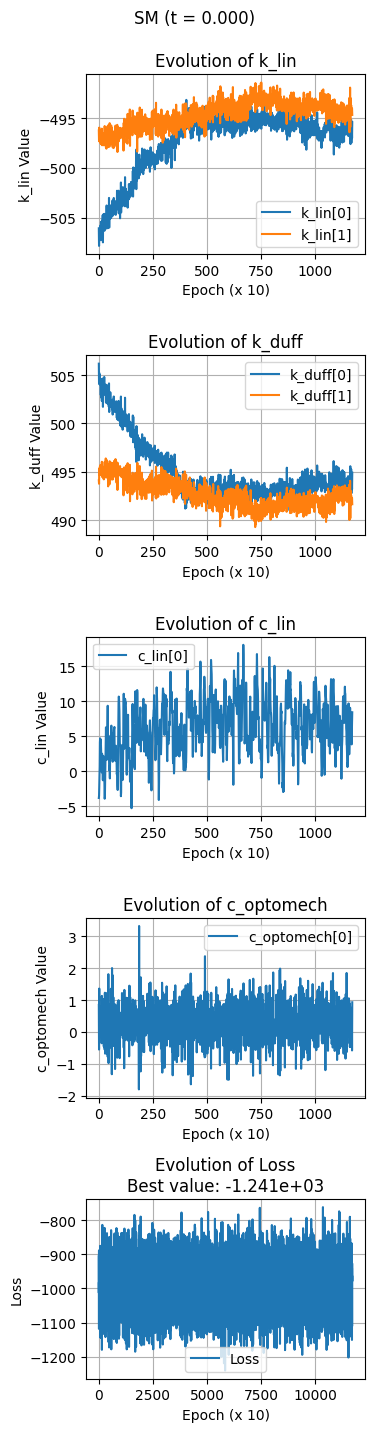

Optimization for time 1.2598952777950248e-10
Epoch 0 - Loss: -1073.4426
Epoch 100 - Loss: -1104.7754
Epoch 200 - Loss: -1018.6870
Epoch 300 - Loss: -971.8135
Epoch 400 - Loss: -1038.9888
Epoch 500 - Loss: -1011.8335
Epoch 600 - Loss: -1018.0300
Epoch 700 - Loss: -1052.5687
Epoch 800 - Loss: -934.0976
Epoch 900 - Loss: -1161.6074
Epoch 1000 - Loss: -969.7956
Epoch 1100 - Loss: -1056.1136
Epoch 1200 - Loss: -1014.4632
Epoch 1300 - Loss: -972.4137
Epoch 1400 - Loss: -904.6246
Epoch 1500 - Loss: -1138.9831
Epoch 1600 - Loss: -891.6280
Epoch 1700 - Loss: -1028.9111
Epoch 1800 - Loss: -797.0640
Epoch 1900 - Loss: -1009.4406
Epoch 2000 - Loss: -993.8939
Epoch 2100 - Loss: -1011.0270
Epoch 2200 - Loss: -1130.2863
Epoch 2300 - Loss: -1012.2044
Epoch 2400 - Loss: -1009.3244
Epoch 2500 - Loss: -860.8143
Epoch 2600 - Loss: -981.5191
Epoch 2700 - Loss: -1023.0436
Epoch 2800 - Loss: -907.2754
Epoch 2900 - Loss: -917.1332
Epoch 3000 - Loss: -1073.3647
Epoch 3100 - Loss: -1022.9701
Epoch 3200 - Loss: 

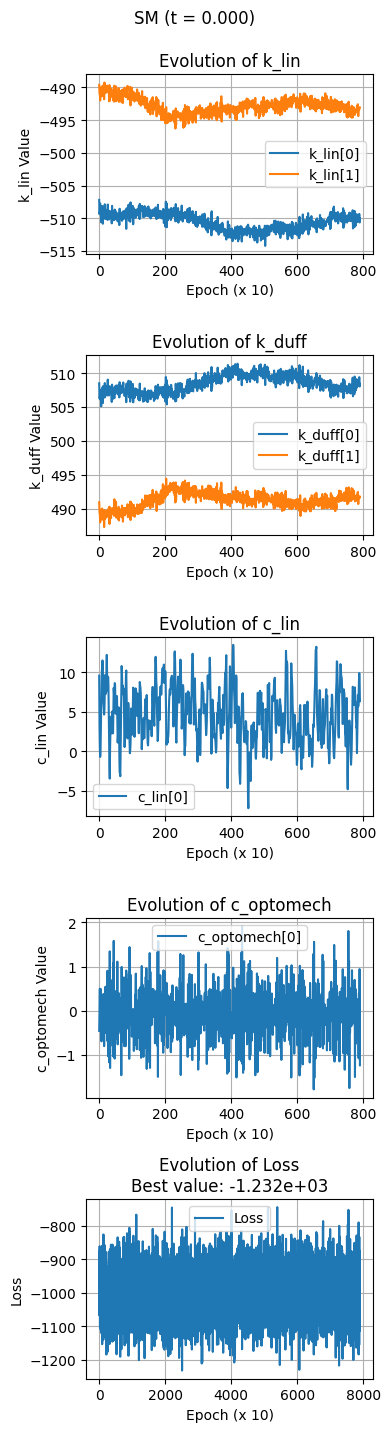

Optimization for time 5.878016072274914e-10
Epoch 0 - Loss: -1044.1059
Epoch 100 - Loss: -958.1311
Epoch 200 - Loss: -997.3339
Epoch 300 - Loss: -1047.3284
Epoch 400 - Loss: -917.0876
Epoch 500 - Loss: -903.9776
Epoch 600 - Loss: -1104.4013
Epoch 700 - Loss: -925.6085
Epoch 800 - Loss: -956.9315
Epoch 900 - Loss: -1043.7883
Epoch 1000 - Loss: -992.1918
Epoch 1100 - Loss: -1048.9712
Epoch 1200 - Loss: -1021.2644
Epoch 1300 - Loss: -941.6643
Epoch 1400 - Loss: -986.4736
Epoch 1500 - Loss: -1020.2125
Epoch 1600 - Loss: -1131.2538
Epoch 1700 - Loss: -1007.1644
Epoch 1800 - Loss: -1067.1268
Epoch 1900 - Loss: -918.6170
Epoch 2000 - Loss: -1001.6211
Epoch 2100 - Loss: -1075.2835
Epoch 2200 - Loss: -1006.3005
Epoch 2300 - Loss: -1053.7293
Epoch 2400 - Loss: -1066.5015
Epoch 2500 - Loss: -966.4685
Epoch 2600 - Loss: -937.2936
Epoch 2700 - Loss: -946.0348
Epoch 2800 - Loss: -981.0677
Epoch 2900 - Loss: -948.1885
Epoch 3000 - Loss: -981.4478
Epoch 3100 - Loss: -1032.6788
Epoch 3200 - Loss: -991.

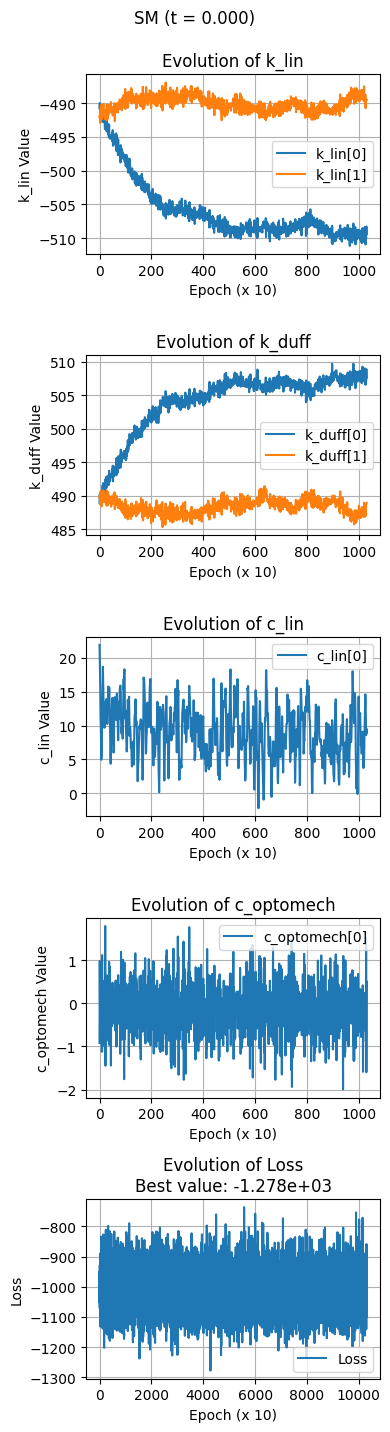

Optimization for time 2.742376573264947e-09
Epoch 0 - Loss: -1001.4239
Epoch 100 - Loss: -867.8437
Epoch 200 - Loss: -1008.6406
Epoch 300 - Loss: -1029.0496
Epoch 400 - Loss: -827.4031
Epoch 500 - Loss: -1054.3070
Epoch 600 - Loss: -1047.7881
Epoch 700 - Loss: -867.3757
Epoch 800 - Loss: -806.9992
Epoch 900 - Loss: -948.2388
Epoch 1000 - Loss: -1013.8382
Epoch 1100 - Loss: -953.6968
Epoch 1200 - Loss: -956.9648
Epoch 1300 - Loss: -1040.4566
Epoch 1400 - Loss: -1086.9645
Epoch 1500 - Loss: -971.2611
Epoch 1600 - Loss: -975.9301
Epoch 1700 - Loss: -997.4338
Epoch 1800 - Loss: -1013.2284
Epoch 1900 - Loss: -1040.1820
Epoch 2000 - Loss: -926.2608
Epoch 2100 - Loss: -995.9899
Epoch 2200 - Loss: -1163.4050
Epoch 2300 - Loss: -1001.5944
Epoch 2400 - Loss: -902.4460
Epoch 2500 - Loss: -1101.9990
Epoch 2600 - Loss: -829.8483
Epoch 2700 - Loss: -899.6484
Epoch 2800 - Loss: -1003.4654
Epoch 2900 - Loss: -940.7041
Epoch 3000 - Loss: -1032.4132
Epoch 3100 - Loss: -966.1182
Epoch 3200 - Loss: -997.0

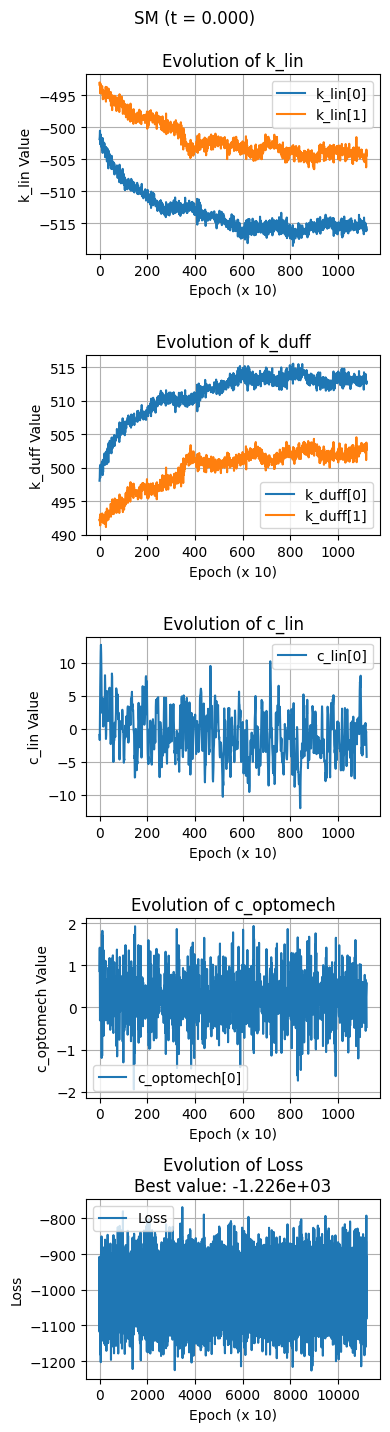

Optimization for time 1.2794502732078704e-08
Epoch 0 - Loss: -1049.2979
Epoch 100 - Loss: -1027.3801
Epoch 200 - Loss: -991.9449
Epoch 300 - Loss: -1100.8122
Epoch 400 - Loss: -928.9156
Epoch 500 - Loss: -1070.2356
Epoch 600 - Loss: -978.8449
Epoch 700 - Loss: -1100.7655
Epoch 800 - Loss: -1090.1608
Epoch 900 - Loss: -1026.6794
Epoch 1000 - Loss: -1037.3528
Epoch 1100 - Loss: -980.9790
Epoch 1200 - Loss: -1104.6535
Epoch 1300 - Loss: -980.4940
Epoch 1400 - Loss: -1120.8230
Epoch 1500 - Loss: -937.3014
Epoch 1600 - Loss: -974.6635
Epoch 1700 - Loss: -999.4939
Epoch 1800 - Loss: -1026.7983
Epoch 1900 - Loss: -1061.5700
Epoch 2000 - Loss: -994.0332
Epoch 2100 - Loss: -1096.6869
Epoch 2200 - Loss: -890.7282
Epoch 2300 - Loss: -986.3108
Epoch 2400 - Loss: -1109.5951
Epoch 2500 - Loss: -946.6510
Epoch 2600 - Loss: -1032.0303
Epoch 2700 - Loss: -973.2448
Epoch 2800 - Loss: -1064.0150
Epoch 2900 - Loss: -976.8364
Epoch 3000 - Loss: -1062.5960
Epoch 3100 - Loss: -1040.6666
Epoch 3200 - Loss: -9

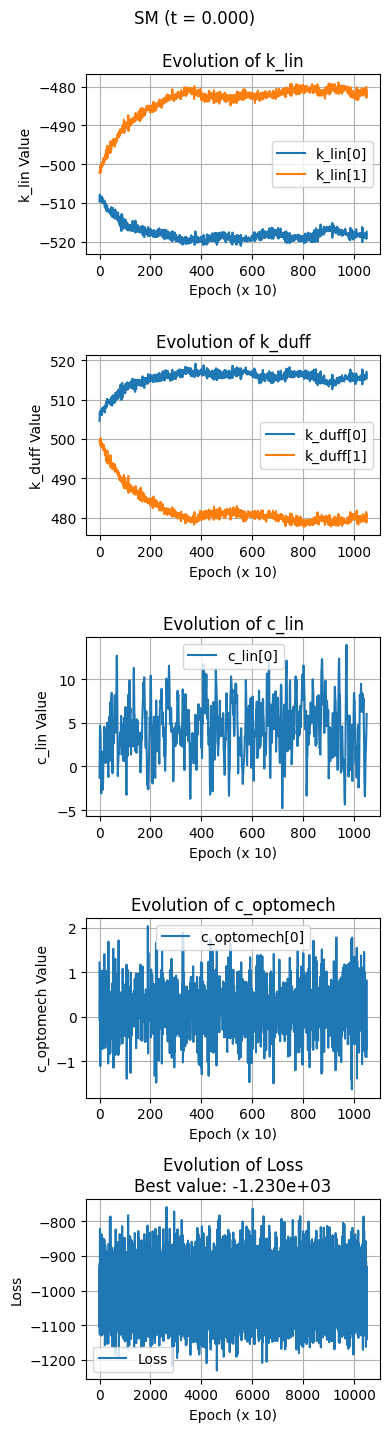

Optimization for time 5.969249509970733e-08
Epoch 0 - Loss: -1029.8670
Epoch 100 - Loss: -925.0222
Epoch 200 - Loss: -968.0157
Epoch 300 - Loss: -1052.2404
Epoch 400 - Loss: -979.0270
Epoch 500 - Loss: -932.8725
Epoch 600 - Loss: -945.3713
Epoch 700 - Loss: -876.2861
Epoch 800 - Loss: -930.9423
Epoch 900 - Loss: -1029.9380
Epoch 1000 - Loss: -1029.2204
Epoch 1100 - Loss: -1051.4407
Epoch 1200 - Loss: -970.3910
Epoch 1300 - Loss: -886.1767
Epoch 1400 - Loss: -997.1294
Epoch 1500 - Loss: -1002.2227
Epoch 1600 - Loss: -1034.5714
Epoch 1700 - Loss: -874.9703
Epoch 1800 - Loss: -1032.6348
Epoch 1900 - Loss: -930.9006
Epoch 2000 - Loss: -949.9121
Epoch 2100 - Loss: -1033.5234
Epoch 2200 - Loss: -1008.4003
Epoch 2300 - Loss: -1072.5967
Epoch 2400 - Loss: -917.2310
Epoch 2500 - Loss: -965.1604
Epoch 2600 - Loss: -1148.4658
Epoch 2700 - Loss: -909.6227
Epoch 2800 - Loss: -1000.1570
Epoch 2900 - Loss: -1062.1073
Epoch 3000 - Loss: -931.0164
Epoch 3100 - Loss: -1100.4067
Epoch 3200 - Loss: -979.2

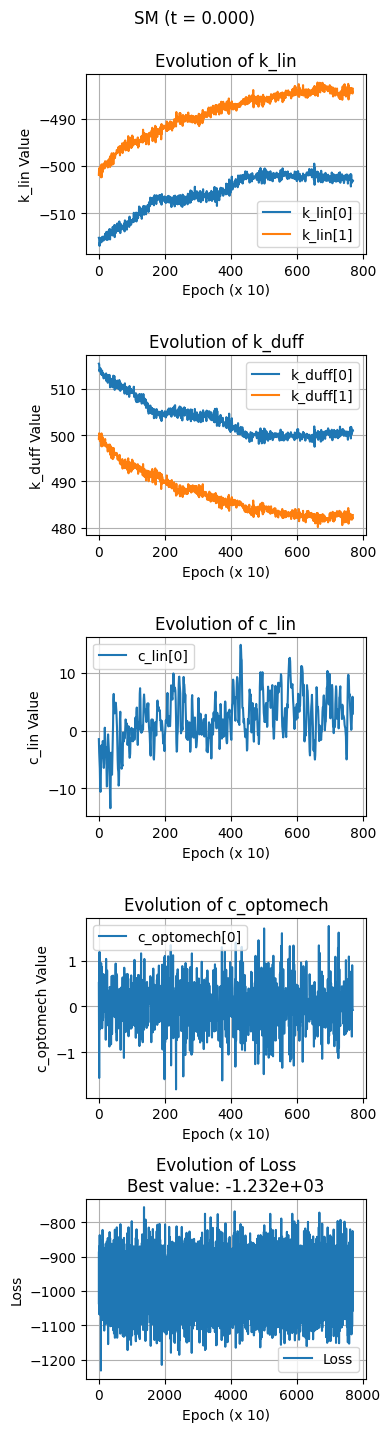

Optimization for time 2.784941350080645e-07
Epoch 0 - Loss: -981.5827
Epoch 100 - Loss: -1047.1782
Epoch 200 - Loss: -897.2370
Epoch 300 - Loss: -981.1376
Epoch 400 - Loss: -1094.6050
Epoch 500 - Loss: -909.3053
Epoch 600 - Loss: -1047.0598
Epoch 700 - Loss: -968.1551
Epoch 800 - Loss: -1028.1567
Epoch 900 - Loss: -883.6960
Epoch 1000 - Loss: -978.6630
Epoch 1100 - Loss: -1039.5641
Epoch 1200 - Loss: -1025.2061
Epoch 1300 - Loss: -964.9621
Epoch 1400 - Loss: -1031.6157
Epoch 1500 - Loss: -1050.8065
Epoch 1600 - Loss: -1067.6915
Epoch 1700 - Loss: -1007.0085
Epoch 1800 - Loss: -1106.6526
Epoch 1900 - Loss: -995.5738
Epoch 2000 - Loss: -953.6878
Epoch 2100 - Loss: -1024.8735
Epoch 2200 - Loss: -1157.0845
Epoch 2300 - Loss: -985.6972
Epoch 2400 - Loss: -1043.0686
Epoch 2500 - Loss: -904.8235
Epoch 2600 - Loss: -1096.9495
Epoch 2700 - Loss: -959.8760
Epoch 2800 - Loss: -1118.3804
Epoch 2900 - Loss: -1002.8997
Epoch 3000 - Loss: -892.0724
Epoch 3100 - Loss: -985.2395
Epoch 3200 - Loss: -892

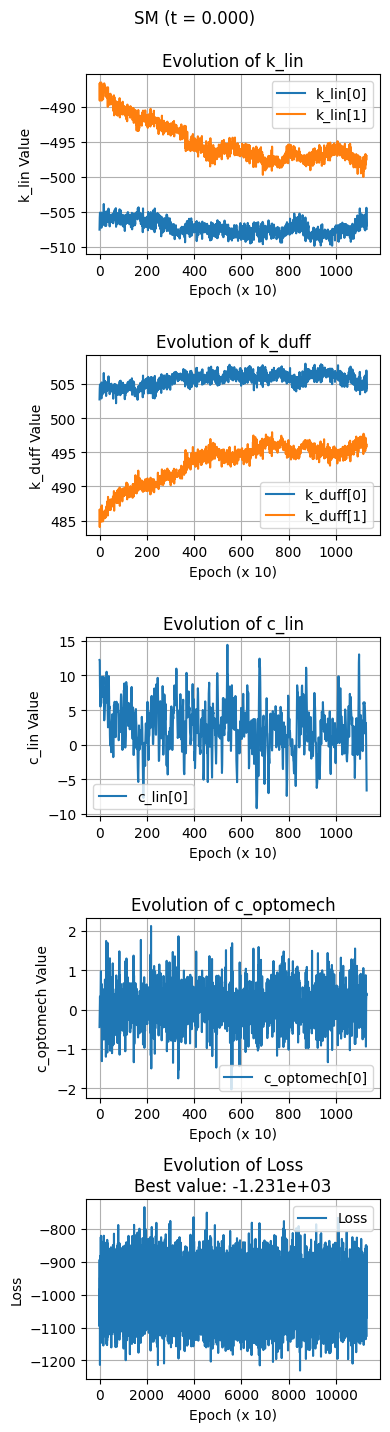

Optimization for time 1.2993087842004144e-06
Epoch 0 - Loss: -1059.2378
Epoch 100 - Loss: -886.4825
Epoch 200 - Loss: -1044.8579
Epoch 300 - Loss: -983.1615
Epoch 400 - Loss: -1099.4101
Epoch 500 - Loss: -1030.3000
Epoch 600 - Loss: -1106.5952
Epoch 700 - Loss: -947.0643
Epoch 800 - Loss: -881.8933
Epoch 900 - Loss: -883.6105
Epoch 1000 - Loss: -913.0430
Epoch 1100 - Loss: -930.7617
Epoch 1200 - Loss: -1098.2256
Epoch 1300 - Loss: -904.1865
Epoch 1400 - Loss: -908.1618
Epoch 1500 - Loss: -1081.9558
Epoch 1600 - Loss: -975.1602
Epoch 1700 - Loss: -926.6587
Epoch 1800 - Loss: -1029.5405
Epoch 1900 - Loss: -962.0827
Epoch 2000 - Loss: -981.8092
Epoch 2100 - Loss: -973.1666
Epoch 2200 - Loss: -971.6143
Epoch 2300 - Loss: -863.9831
Epoch 2400 - Loss: -959.1546
Epoch 2500 - Loss: -1054.9399
Epoch 2600 - Loss: -960.1017
Epoch 2700 - Loss: -969.9242
Epoch 2800 - Loss: -875.1142
Epoch 2900 - Loss: -884.3283
Epoch 3000 - Loss: -954.5289
Epoch 3100 - Loss: -937.2557
Epoch 3200 - Loss: -1001.9557


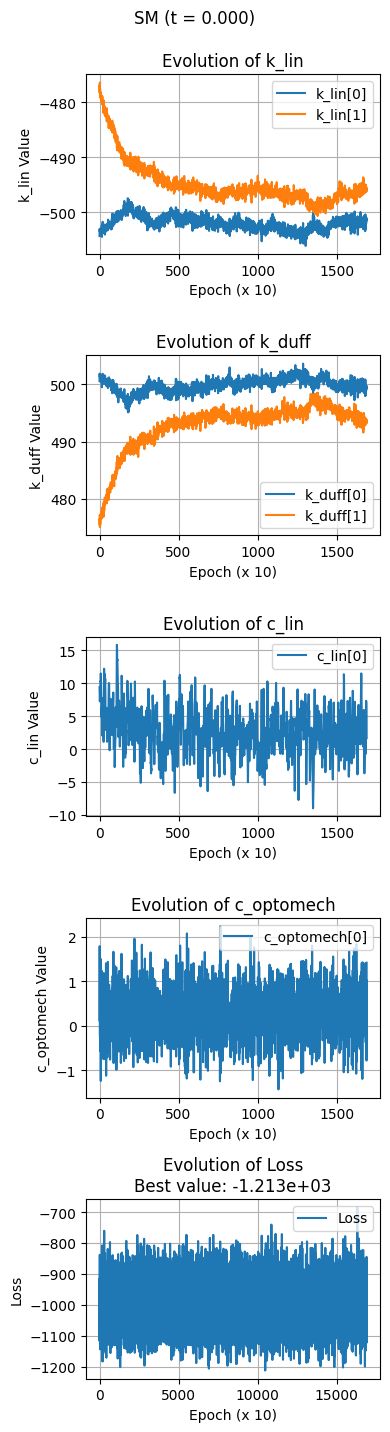

Optimization for time 6.061898993497579e-06
Epoch 0 - Loss: -1008.7501
Epoch 100 - Loss: -893.6939
Epoch 200 - Loss: -994.2685
Epoch 300 - Loss: -971.0844
Epoch 400 - Loss: -1032.5785
Epoch 500 - Loss: -1043.4156
Epoch 600 - Loss: -964.2342
Epoch 700 - Loss: -943.7802
Epoch 800 - Loss: -1042.5272
Epoch 900 - Loss: -1023.9807
Epoch 1000 - Loss: -998.1113
Epoch 1100 - Loss: -816.8600
Epoch 1200 - Loss: -1017.1632
Epoch 1300 - Loss: -1019.4230
Epoch 1400 - Loss: -983.4623
Epoch 1500 - Loss: -969.9547
Epoch 1600 - Loss: -866.9385
Epoch 1700 - Loss: -1038.1722
Epoch 1800 - Loss: -1016.9133
Epoch 1900 - Loss: -1044.6206
Epoch 2000 - Loss: -909.6024
Epoch 2100 - Loss: -1006.3859
Epoch 2200 - Loss: -1034.0242
Epoch 2300 - Loss: -1059.1734
Epoch 2400 - Loss: -915.1428
Epoch 2500 - Loss: -857.9498
Epoch 2600 - Loss: -943.5867
Epoch 2700 - Loss: -1014.4411
Epoch 2800 - Loss: -1091.3618
Epoch 2900 - Loss: -954.7081
Epoch 3000 - Loss: -992.6746
Epoch 3100 - Loss: -958.3213
Epoch 3200 - Loss: -1020.

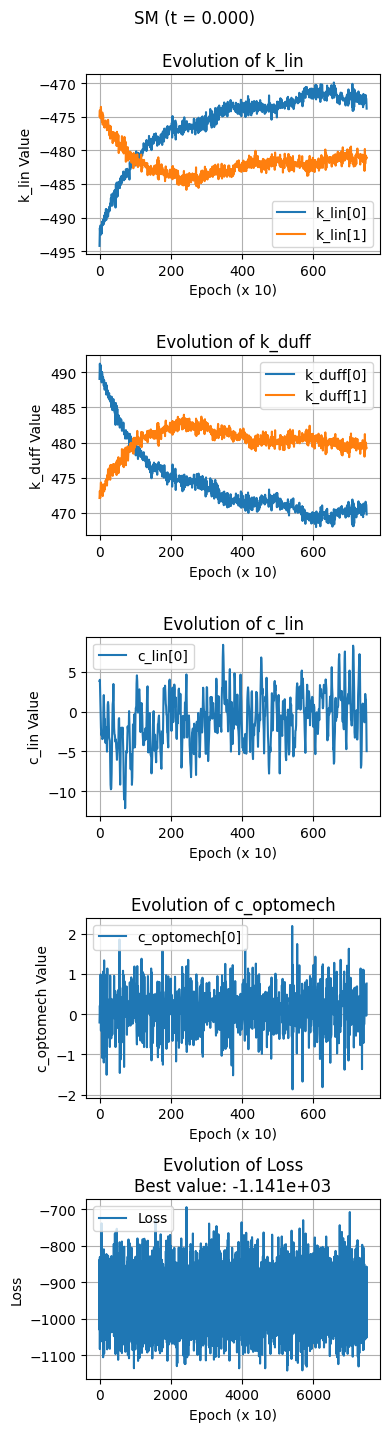

Optimization for time 2.8281667802300318e-05
Epoch 0 - Loss: -1022.5035
Epoch 100 - Loss: -967.2815
Epoch 200 - Loss: -906.3113
Epoch 300 - Loss: -954.8133
Epoch 400 - Loss: -895.3634
Epoch 500 - Loss: -886.5862
Epoch 600 - Loss: -924.8248
Epoch 700 - Loss: -1081.0236
Epoch 800 - Loss: -930.9899
Epoch 900 - Loss: -911.2214
Epoch 1000 - Loss: -944.7779
Epoch 1100 - Loss: -978.4393
Epoch 1200 - Loss: -1005.1925
Epoch 1300 - Loss: -876.6605
Epoch 1400 - Loss: -945.7533
Epoch 1500 - Loss: -924.8833
Epoch 1600 - Loss: -923.2831
Epoch 1700 - Loss: -976.3703
Epoch 1800 - Loss: -941.0770
Epoch 1900 - Loss: -967.5802
Epoch 2000 - Loss: -919.5157
Epoch 2100 - Loss: -912.9231
Epoch 2200 - Loss: -1001.8060
Epoch 2300 - Loss: -1000.0872
Epoch 2400 - Loss: -905.1764
Epoch 2500 - Loss: -954.9569
Epoch 2600 - Loss: -979.9427
Epoch 2700 - Loss: -978.6225
Epoch 2800 - Loss: -996.2955
Epoch 2900 - Loss: -950.2504
Epoch 3000 - Loss: -1032.0046
Epoch 3100 - Loss: -981.0427
Epoch 3200 - Loss: -833.4395
Epoc

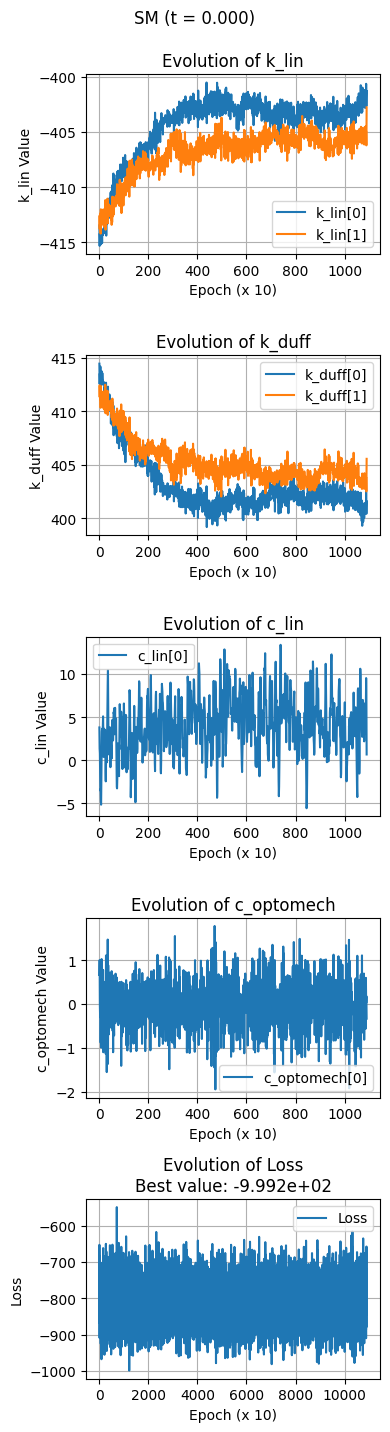

Optimization for time 0.00013194755216767062
Epoch 0 - Loss: -775.7407
Epoch 100 - Loss: -813.3944
Epoch 200 - Loss: -818.4717
Epoch 300 - Loss: -792.0758
Epoch 400 - Loss: -754.3923
Epoch 500 - Loss: -820.2577
Epoch 600 - Loss: -754.0862
Epoch 700 - Loss: -812.4177
Epoch 800 - Loss: -722.0351
Epoch 900 - Loss: -839.7309
Epoch 1000 - Loss: -771.0905
Epoch 1100 - Loss: -761.7721
Epoch 1200 - Loss: -860.1954
Epoch 1300 - Loss: -739.4830
Epoch 1400 - Loss: -795.5661
Epoch 1500 - Loss: -769.4137
Epoch 1600 - Loss: -818.8438
Epoch 1700 - Loss: -790.2923
Epoch 1800 - Loss: -780.2327
Epoch 1900 - Loss: -765.7096
Epoch 2000 - Loss: -753.1153
Epoch 2100 - Loss: -734.9694
Epoch 2200 - Loss: -744.5641
Epoch 2300 - Loss: -786.5293
Epoch 2400 - Loss: -752.5256
Epoch 2500 - Loss: -678.8447
Epoch 2600 - Loss: -744.4567
Epoch 2700 - Loss: -781.7093
Epoch 2800 - Loss: -744.0266
Epoch 2900 - Loss: -810.9192
Epoch 3000 - Loss: -838.4216
Epoch 3100 - Loss: -813.6707
Epoch 3200 - Loss: -816.0508
Epoch 3300

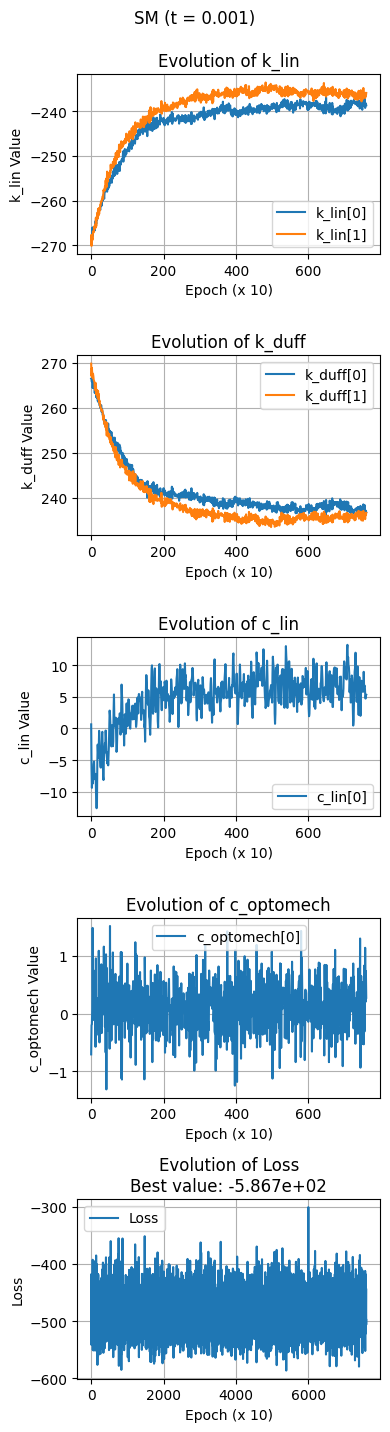

Optimization for time 0.0006155986501483506
Epoch 0 - Loss: -494.4106
Epoch 100 - Loss: -442.1286
Epoch 200 - Loss: -443.3091
Epoch 300 - Loss: -478.1926
Epoch 400 - Loss: -415.7573
Epoch 500 - Loss: -458.2473
Epoch 600 - Loss: -419.0733
Epoch 700 - Loss: -458.7679
Epoch 800 - Loss: -369.0495
Epoch 900 - Loss: -412.7963
Epoch 1000 - Loss: -438.0467
Epoch 1100 - Loss: -512.6673
Epoch 1200 - Loss: -496.5382
Epoch 1300 - Loss: -495.9741
Epoch 1400 - Loss: -462.5638
Epoch 1500 - Loss: -453.3095
Epoch 1600 - Loss: -451.6297
Epoch 1700 - Loss: -377.5914
Epoch 1800 - Loss: -498.4302
Epoch 1900 - Loss: -455.5434
Epoch 2000 - Loss: -400.0602
Epoch 2100 - Loss: -410.2031
Epoch 2200 - Loss: -465.5809
Epoch 2300 - Loss: -458.0893
Epoch 2400 - Loss: -490.2982
Epoch 2500 - Loss: -462.3092
Epoch 2600 - Loss: -499.9107
Epoch 2700 - Loss: -458.9259
Epoch 2800 - Loss: -456.5401
Epoch 2900 - Loss: -460.8585
Epoch 3000 - Loss: -411.9703
Epoch 3100 - Loss: -449.2838
Epoch 3200 - Loss: -423.0652
Epoch 3300 

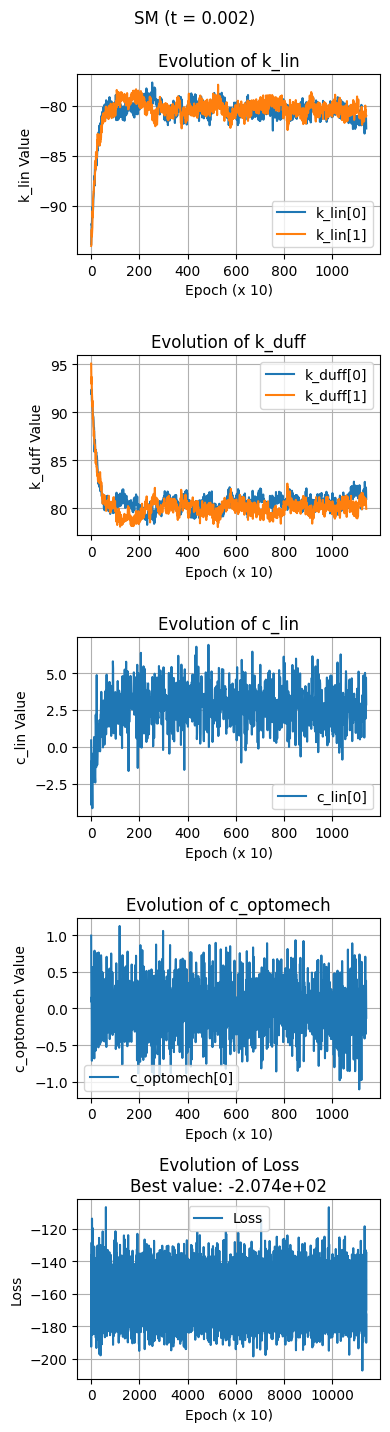

Optimization for time 0.002872063117797826
Epoch 0 - Loss: -150.4346
Epoch 100 - Loss: -158.3623
Epoch 200 - Loss: -167.4830
Epoch 300 - Loss: -154.7501
Epoch 400 - Loss: -148.1084
Epoch 500 - Loss: -149.1297
Epoch 600 - Loss: -130.6464
Epoch 700 - Loss: -125.5454
Epoch 800 - Loss: -141.7113
Epoch 900 - Loss: -154.5951
Epoch 1000 - Loss: -143.8662
Epoch 1100 - Loss: -142.0858
Epoch 1200 - Loss: -158.1753
Epoch 1300 - Loss: -150.9525
Epoch 1400 - Loss: -140.5108
Epoch 1500 - Loss: -145.3413
Epoch 1600 - Loss: -145.0772
Epoch 1700 - Loss: -152.9539
Epoch 1800 - Loss: -149.5217
Epoch 1900 - Loss: -136.3258
Epoch 2000 - Loss: -130.5013
Epoch 2100 - Loss: -142.3090
Epoch 2200 - Loss: -146.6172
Epoch 2300 - Loss: -130.9494
Epoch 2400 - Loss: -151.6516
Epoch 2500 - Loss: -150.3910
Epoch 2600 - Loss: -145.8646
Epoch 2700 - Loss: -145.3660
Epoch 2800 - Loss: -133.9030
Epoch 2900 - Loss: -157.5616
Epoch 3000 - Loss: -142.4556
Epoch 3100 - Loss: -155.3042
Epoch 3200 - Loss: -142.9883
Epoch 3300 -

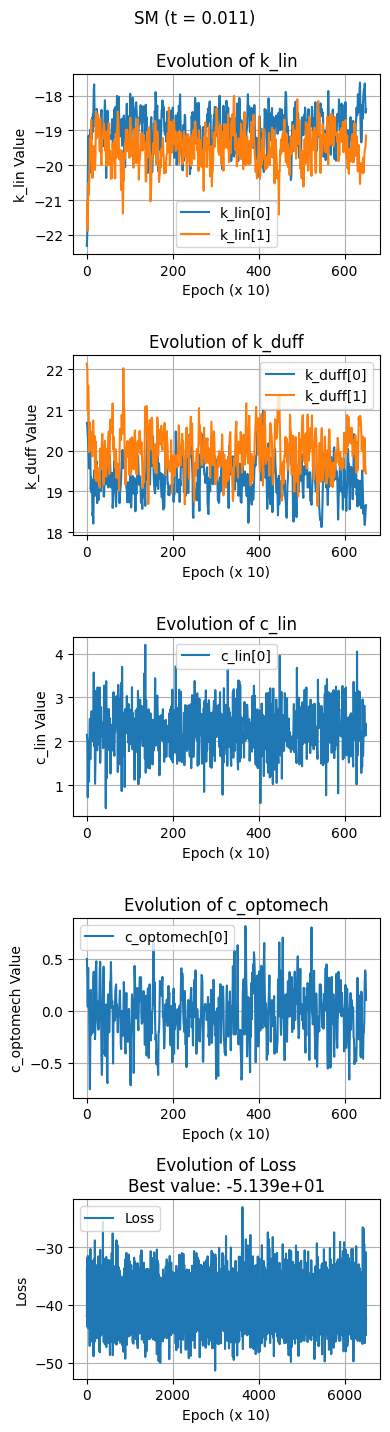

Optimization for time 0.013399552696593368
Epoch 0 - Loss: -32.6376
Epoch 100 - Loss: -35.7091
Epoch 200 - Loss: -28.7245
Epoch 300 - Loss: -31.9073
Epoch 400 - Loss: -34.0619
Epoch 500 - Loss: -34.6238
Epoch 600 - Loss: -37.7111
Epoch 700 - Loss: -33.1333
Epoch 800 - Loss: -33.9245
Epoch 900 - Loss: -26.8980
Epoch 1000 - Loss: -34.6530
Epoch 1100 - Loss: -31.6751
Epoch 1200 - Loss: -32.4819
Epoch 1300 - Loss: -34.4666
Epoch 1400 - Loss: -24.6937
Epoch 1500 - Loss: -37.1839
Epoch 1600 - Loss: -34.1504
Epoch 1700 - Loss: -31.3031
Epoch 1800 - Loss: -33.5831
Epoch 1900 - Loss: -33.0386
Epoch 2000 - Loss: -33.3039
Epoch 2100 - Loss: -33.0727
Epoch 2200 - Loss: -32.7001
Epoch 2300 - Loss: -34.1418
Epoch 2400 - Loss: -34.5708
Epoch 2500 - Loss: -32.7696
Epoch 2600 - Loss: -31.7980
Epoch 2700 - Loss: -34.0391
Epoch 2800 - Loss: -35.4461
Epoch 2900 - Loss: -38.5103
Epoch 3000 - Loss: -26.9278
Epoch 3100 - Loss: -31.9539
Epoch 3200 - Loss: -32.5765
Epoch 3300 - Loss: -32.5245
Epoch 3400 - Loss

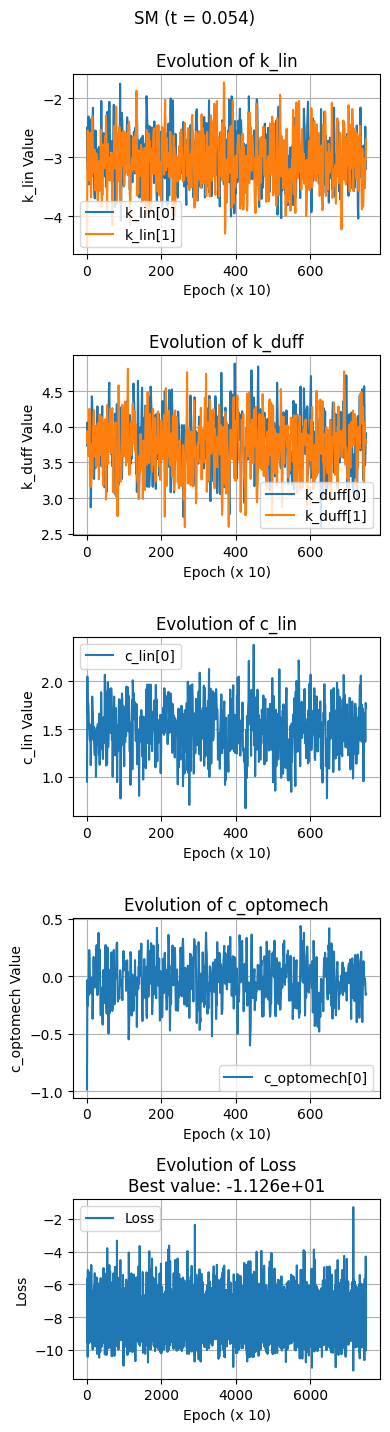

Optimization for time 0.06251534353689707
Epoch 0 - Loss: -4.3340
Epoch 100 - Loss: -6.5535
Epoch 200 - Loss: -5.9222
Epoch 300 - Loss: -6.9986
Epoch 400 - Loss: -6.7150
Epoch 500 - Loss: -4.6762
Epoch 600 - Loss: -7.6736
Epoch 700 - Loss: -7.9970
Epoch 800 - Loss: -7.7218
Epoch 900 - Loss: -6.8712
Epoch 1000 - Loss: -6.6415
Epoch 1100 - Loss: -7.0150
Epoch 1200 - Loss: -7.7004
Epoch 1300 - Loss: -8.2121
Epoch 1400 - Loss: -7.9257
Epoch 1500 - Loss: -4.3752
Epoch 1600 - Loss: -6.8940
Epoch 1700 - Loss: -5.4411
Epoch 1800 - Loss: -6.7645
Epoch 1900 - Loss: -6.1757
Epoch 2000 - Loss: -7.0693
Epoch 2100 - Loss: -8.7519
Epoch 2200 - Loss: -7.6787
Epoch 2300 - Loss: -5.9175
Epoch 2400 - Loss: -5.8677
Epoch 2500 - Loss: -7.9878
Epoch 2600 - Loss: -6.0074
Epoch 2700 - Loss: -6.0103
Epoch 2800 - Loss: -8.0699
Epoch 2900 - Loss: -6.5516
Epoch 3000 - Loss: -7.1827
Epoch 3100 - Loss: -5.7463
Epoch 3200 - Loss: -6.9985
Epoch 3300 - Loss: -6.3264
Epoch 3400 - Loss: -8.0718
Epoch 3500 - Loss: -4.082

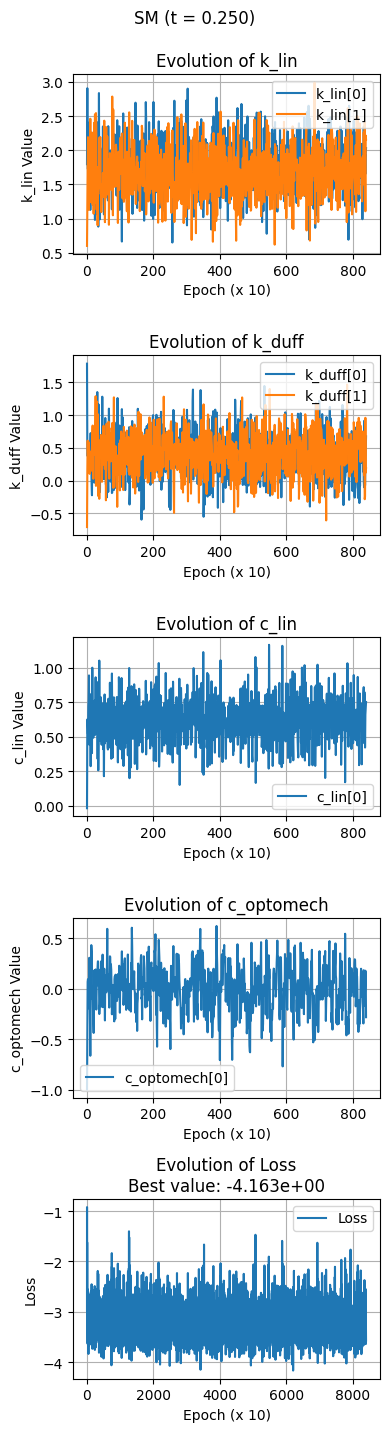

Optimization for time 0.29166407760237023
Epoch 0 - Loss: -3.1227
Epoch 100 - Loss: -3.7544
Epoch 200 - Loss: -3.2085
Epoch 300 - Loss: -3.4372
Epoch 400 - Loss: -3.0549
Epoch 500 - Loss: -3.7583
Epoch 600 - Loss: -3.0942
Epoch 700 - Loss: -3.2121
Epoch 800 - Loss: -3.5280
Epoch 900 - Loss: -3.7663
Epoch 1000 - Loss: -3.3128
Epoch 1100 - Loss: -3.1903
Epoch 1200 - Loss: -3.4971
Epoch 1300 - Loss: -3.3465
Epoch 1400 - Loss: -3.4078
Epoch 1500 - Loss: -2.9634
Epoch 1600 - Loss: -2.5926
Epoch 1700 - Loss: -3.4601
Epoch 1800 - Loss: -3.8088
Epoch 1900 - Loss: -3.4634
Epoch 2000 - Loss: -3.2087
Epoch 2100 - Loss: -3.3200
Epoch 2200 - Loss: -3.1770
Epoch 2300 - Loss: -3.6508
Epoch 2400 - Loss: -3.3461
Epoch 2500 - Loss: -3.2971
Epoch 2600 - Loss: -3.1888
Epoch 2700 - Loss: -3.0955
Epoch 2800 - Loss: -2.9123
Epoch 2900 - Loss: -3.3051
Epoch 3000 - Loss: -3.2778
Epoch 3100 - Loss: -3.0045
Epoch 3200 - Loss: -3.3756
Epoch 3300 - Loss: -2.5815
Epoch 3400 - Loss: -3.4495
Epoch 3500 - Loss: -3.307

In [13]:
load_param_histories = False

if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(f"{output_dir}/params_history.npy")
else:
    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    # mask = mask.at[-1].set(0.0)
    

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"Optimization for time {t_curr}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=True,
                    path=output_dir,
                    param_names=params_names
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)


### Smoothen and interpolate parameter evolution

In [ ]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths = [10, 10, 10, 10, 10, 10, 10, 10], poly_orders = [3, 3, 3, 3, 3, 3, 3, 3])
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)


plot_parameter_as_fn_of_time(params_names, forward_time_pts,forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc) 

ImportError: cannot import name 'plot_parameter_as_fn_of_time' from 'physical_diffusion_fns.plotting_fns' (/home/cbosch/dev/oscillator_dev/mechanical-p-bit/projects/physical-diffusion-models/physical_diffusion_fns/plotting_fns.py)

### Run reverse SDE:

In [15]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:k_lin_0.shape[0]].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_forward**2 * forward_params
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

In [17]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

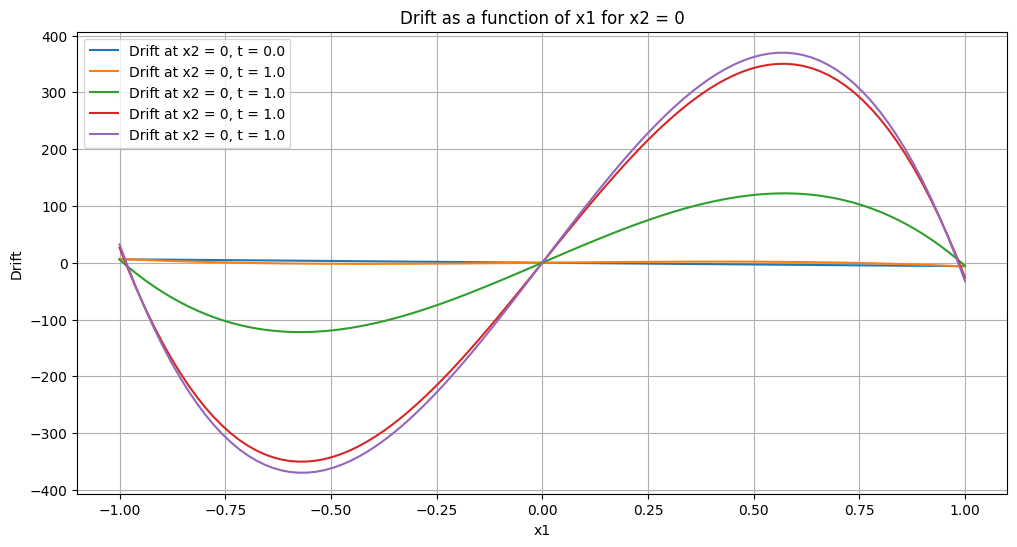

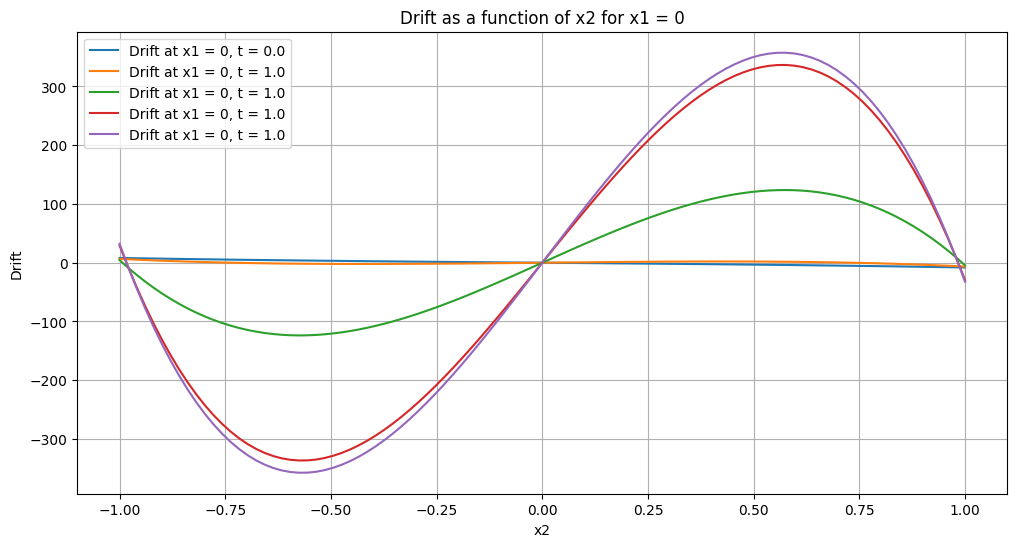

In [18]:
# Assuming drift_fn is already defined and takes (time, state, args) as input
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
n_trajectories = 2000
key, subkey = jr.split(key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=1, samples0=samples_0, key=subkey)
# Sample initial conditions from N(0, I)
# n_trajectories = 1000  # or any other number of trajectories you need
# n_dimensions = 2  # assuming 2D, adjust as necessary
# key, subkey = jr.split(key)
# initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [20]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


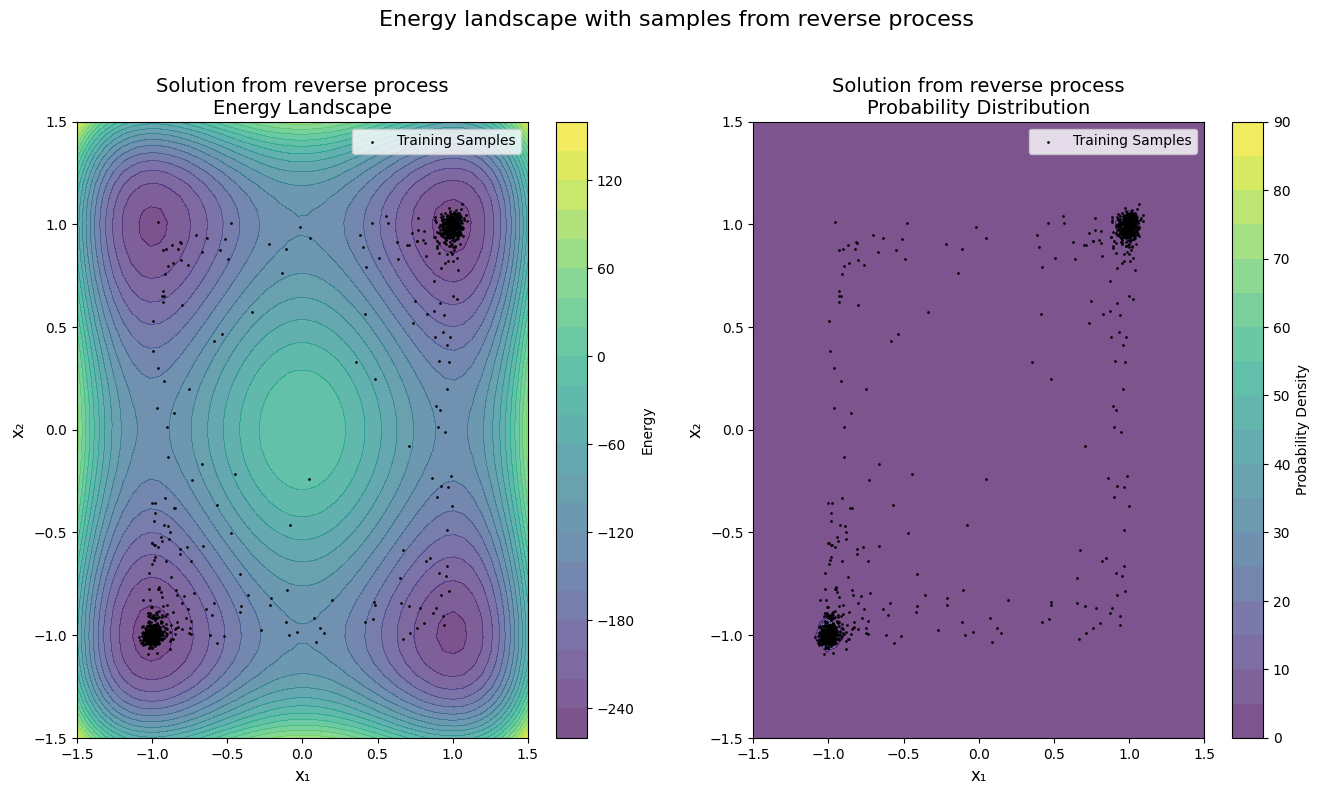

In [21]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


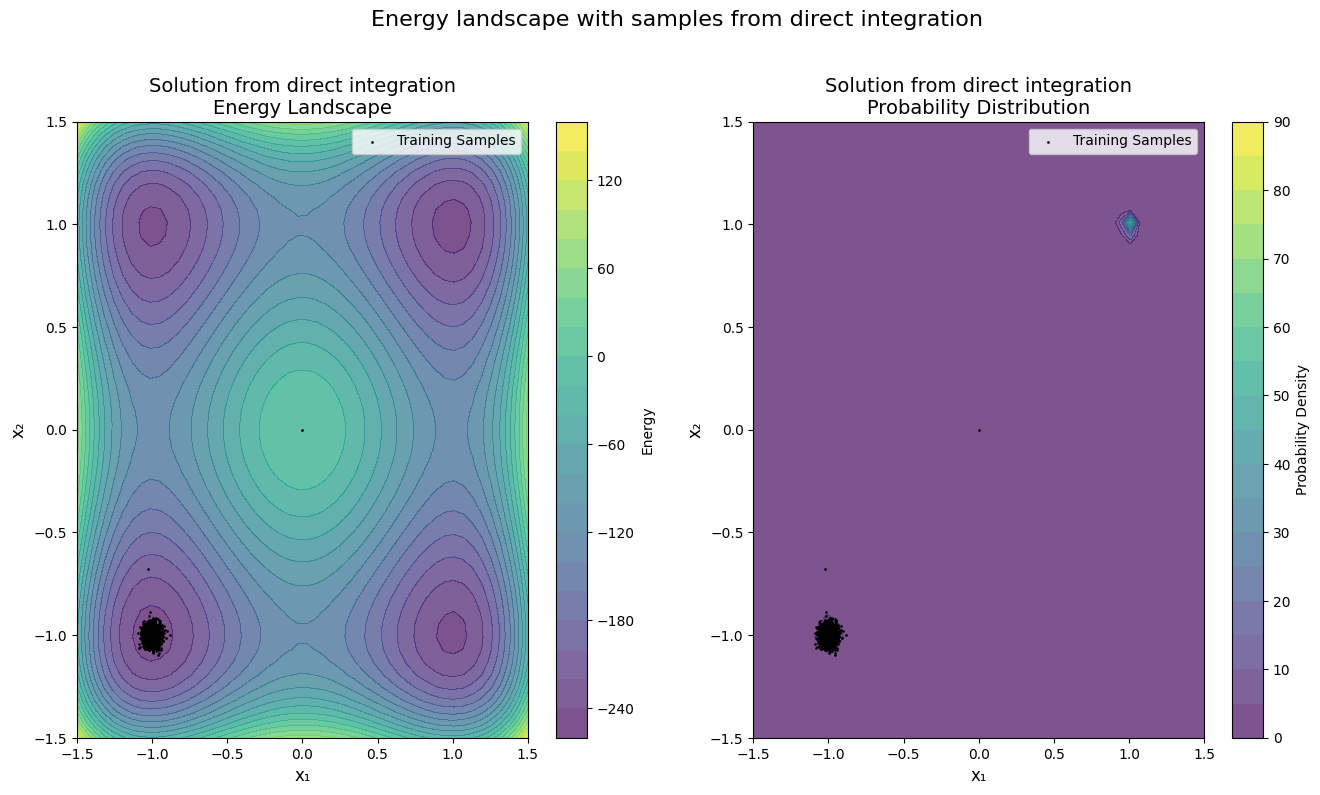

In [22]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

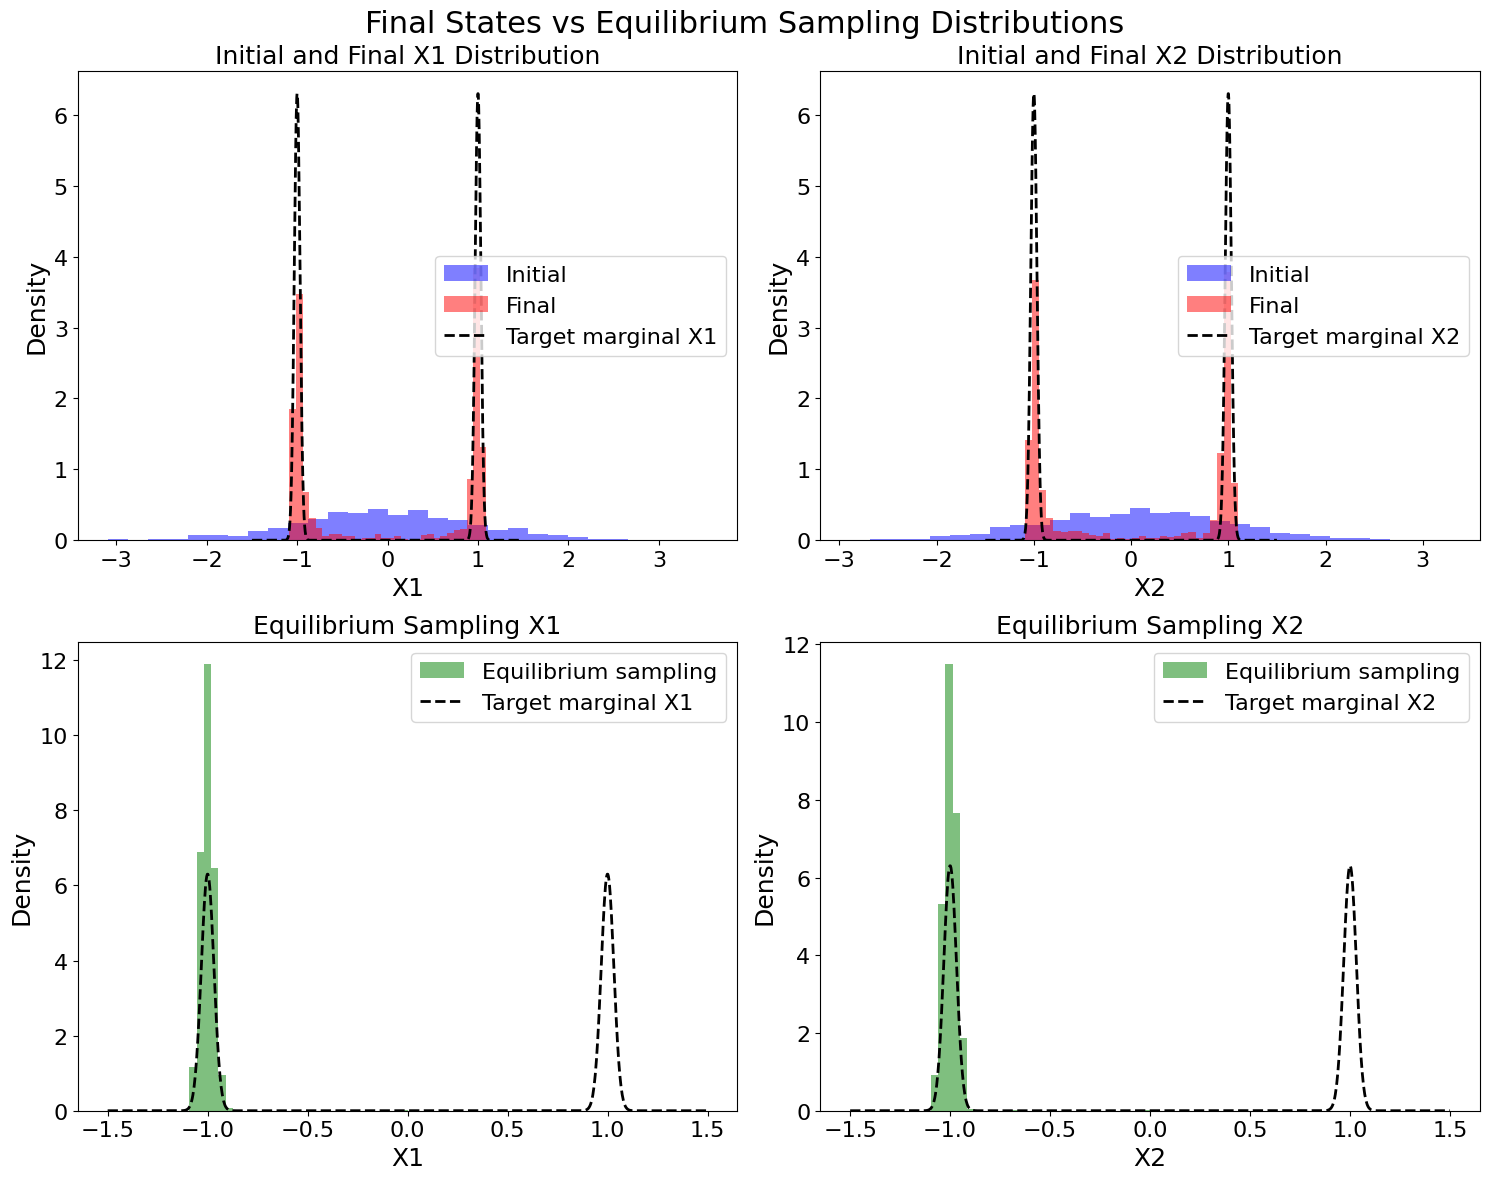

In [23]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()